# Executive Summary

Customer churn is a major challenge for subscription-based businesses, as losing existing customers can significantly impact long-term revenue and profitability. This project aims to identify customers who are at risk of churning and uncover the key factors influencing their decision to leave. By leveraging historical customer information, transaction records, and user activity data, predictive analytics can help businesses take proactive actions to improve customer retention.

To achieve this objective, a **LightGBM** classification model was developed to predict the likelihood of customer churn. The model analyzes customer demographics, subscription history, payment behavior, pricing changes, membership duration, and listening activity to estimate each customer's probability of leaving the service. In addition to generating accurate churn predictions, Explainable AI (SHAP) was used to interpret the model's decisions and identify the most influential factors driving customer churn.

The primary business objective of this analysis is to **reduce customer churn by identifying at-risk customers and understanding the key drivers behind churn**. The insights presented in this report translate the model's predictions into actionable business recommendations that can support customer retention strategies, improve marketing effectiveness, optimize subscription plans, and strengthen long-term customer loyalty.

This report focuses exclusively on the **business analysis** of the project, presenting visual insights, model explanations, and strategic recommendations. Detailed information regarding data preprocessing, feature engineering, and model development is documented separately in the accompanying technical notebooks.


## Business Problem

Customer churn directly impacts subscription revenue and customer lifetime value. The objective of this project is to identify customers at high risk of churn using a LightGBM model and translate those predictions into actionable business recommendations.

## KKBOX Customer Churn Prediction

### Business Intelligence Dashboard

## Environment Setup

 ### Import Libraries

In [ ]:
import polars as pl
import pandas as pd
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap
import matplotlib.pyplot as plt
SEED = 42

### Load Engineered Dataset

In [ ]:
# ==========================================================
# LOAD ENGINEERED DATASET
# Supports:
#   - Parquet
#   - CSV
# Returns:
#   df_pd : Pandas DataFrame
#   df_pl : Polars DataFrame
# ==========================================================

DATA_PATH = "/kaggle/input/YOUR_DATASET/final_train.parquet"
# DATA_PATH = "/kaggle/input/YOUR_DATASET/final_train.csv"

extension = os.path.splitext(DATA_PATH)[1].lower()

if extension == ".parquet":

    print("Loading Parquet Dataset...")

    df_pl = pl.read_parquet(DATA_PATH)
    df_pd = df_pl.to_pandas()

elif extension == ".csv":

    print("Loading CSV Dataset...")

    df_pd = pd.read_csv(DATA_PATH)
    df_pl = pl.from_pandas(df_pd)

else:
    raise ValueError(f"Unsupported file format: {extension}")

print(f"Pandas Shape : {df_pd.shape}")
print(f"Polars Shape : {df_pl.shape}")

display(df_pd.head())

### Load Trained LightGBM Model

In [ ]:
MODEL_PATH = "/kaggle/input/YOUR_LIGHTGBM_MODEL/lightgbm_model.pkl"

model = joblib.load(MODEL_PATH)

print("LightGBM model loaded successfully!")

### Reconstructing the Original Test Dataset
- To ensure that all business insights and visualizations are generated from unseen data, the original test dataset used during model evaluation was reconstructed using the same train/test split and random seed as in the model training notebook. This guarantees that all analyses reflect the model's performance on data that was never seen during training.

In [ ]:
from sklearn.model_selection import train_test_split
df = final_train_clean
TARGET = 'is_churn'
msno = df['msno']
X = df.drop(['msno', TARGET])
y = df[TARGET]
# First split: 80% train+validation, 20% test
X_train, X_test, y_train, y_test, msno_train, msno_test = train_test_split(
    X,
    y,
    msno,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# Second split: 64% train, 16% validation
X_train, X_valid, y_train, y_valid, msno_train, msno_valid = train_test_split(
    X_train,
    y_train,
    msno_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

In [ ]:
# ==========================================================
# Categorical Features
# ==========================================================

categorical_features = [
    "city",
    "gender",
    "registered_via",
    "last_payment_method"
]

# Convert Polars DataFrame to Pandas
X_test_pd = X_test.to_pandas()

# Convert categorical columns to pandas category dtype
for col in categorical_features:
    if col in X_test_pd.columns:
        X_test_pd[col] = X_test_pd[col].astype("category")

# ==========================================================
# Generate Predictions
# ==========================================================

probability = model.predict_proba(X_test_pd)[:, 1]

# ==========================================================
# Create Business Dataset
# ==========================================================

business_df = X_test_pd.copy()

business_df["msno"] = msno_test.to_pandas().values
business_df["Actual Churn"] = y_test.to_pandas().values
business_df["Churn Probability"] = probability

### Creating Business



In [ ]:
def risk_level(prob):
    if prob >= 0.80:
        return "High Risk"
    elif prob >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

business_df["Risk Level"] = business_df["Churn Probability"].apply(risk_level)
business_df = business_df.sort_values(
    "Churn Probability",
    ascending=False
)

business_df.sample(5)

## How healthy is the customer base?

### Executive KPI Dashboard

**Note:** The Revenue at Risk metric is an illustrative estimate based on an assumed average monthly subscription value of $149 per customer.

In [ ]:
# ==========================================================
# BUSINESS ASSUMPTION
# ==========================================================

MONTHLY_REVENUE = 149   # Example monthly subscription revenue

# ==========================================================
# KPI CALCULATIONS
# ==========================================================

total_customers = len(business_df)

high_risk = (
    business_df["Churn Probability"] >= 0.80
).sum()

predicted_rate = (
    high_risk / total_customers
) * 100

revenue_at_risk = (
    business_df["Churn Probability"] * MONTHLY_REVENUE
).sum()

# ==========================================================
# EXECUTIVE KPI DASHBOARD
# ==========================================================

fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}]
    ],
    vertical_spacing=0.28,
    horizontal_spacing=0.15
)

# ==========================================================
# Total Customers
# ==========================================================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=total_customers,

        number=dict(
            valueformat=".3s",
            font=dict(
                size=64,
                color="#1F77B4"
            )
        ),

        title=dict(
            text="<b>▣ Total Customers</b>",
            font=dict(size=24)
        )

    ),

    row=1,
    col=1

)

# ==========================================================
# High Risk Customers
# ==========================================================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=high_risk,

        number=dict(
            valueformat=".3s",
            font=dict(
                size=64,
                color="crimson"
            )
        ),

        title=dict(
            text="<b>⚠ High-Risk Customers</b>",
            font=dict(size=24)
        )

    ),

    row=1,
    col=2

)

# ==========================================================
# Predicted Churn Rate
# ==========================================================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=predicted_rate,

        number=dict(
            suffix="%",
            valueformat=".2f",
            font=dict(
                size=64,
                color="#FF8C00"
            )
        ),

        title=dict(
            text="<b>◆ Predicted Churn Rate</b>",
            font=dict(size=24)
        )

    ),

    row=2,
    col=1

)

# ==========================================================
# Revenue at Risk
# ==========================================================

fig.add_trace(

    go.Indicator(

        mode="number",

        value=revenue_at_risk,

        number=dict(
            prefix="$",
            valueformat=".3s",
            font=dict(
                size=64,
                color="green"
            )
        ),

        title=dict(
            text="<b>$ Revenue at Risk</b>",
            font=dict(size=24)
        )

    ),

    row=2,
    col=2

)

# ==========================================================
# LAYOUT
# ==========================================================

fig.update_layout(

    title=dict(

        text=(
            "<b>Executive Customer Churn Dashboard</b>"
            "<br><sup>Key performance indicators generated using the optimized "
            "LightGBM churn prediction model</sup>"
        ),

        x=0.5,

        font=dict(size=30)

    ),

    template="plotly_white",

    height=650,

    width=1200,

    margin=dict(
        l=40,
        r=40,
        t=110,
        b=40
    )

)
fig.show()

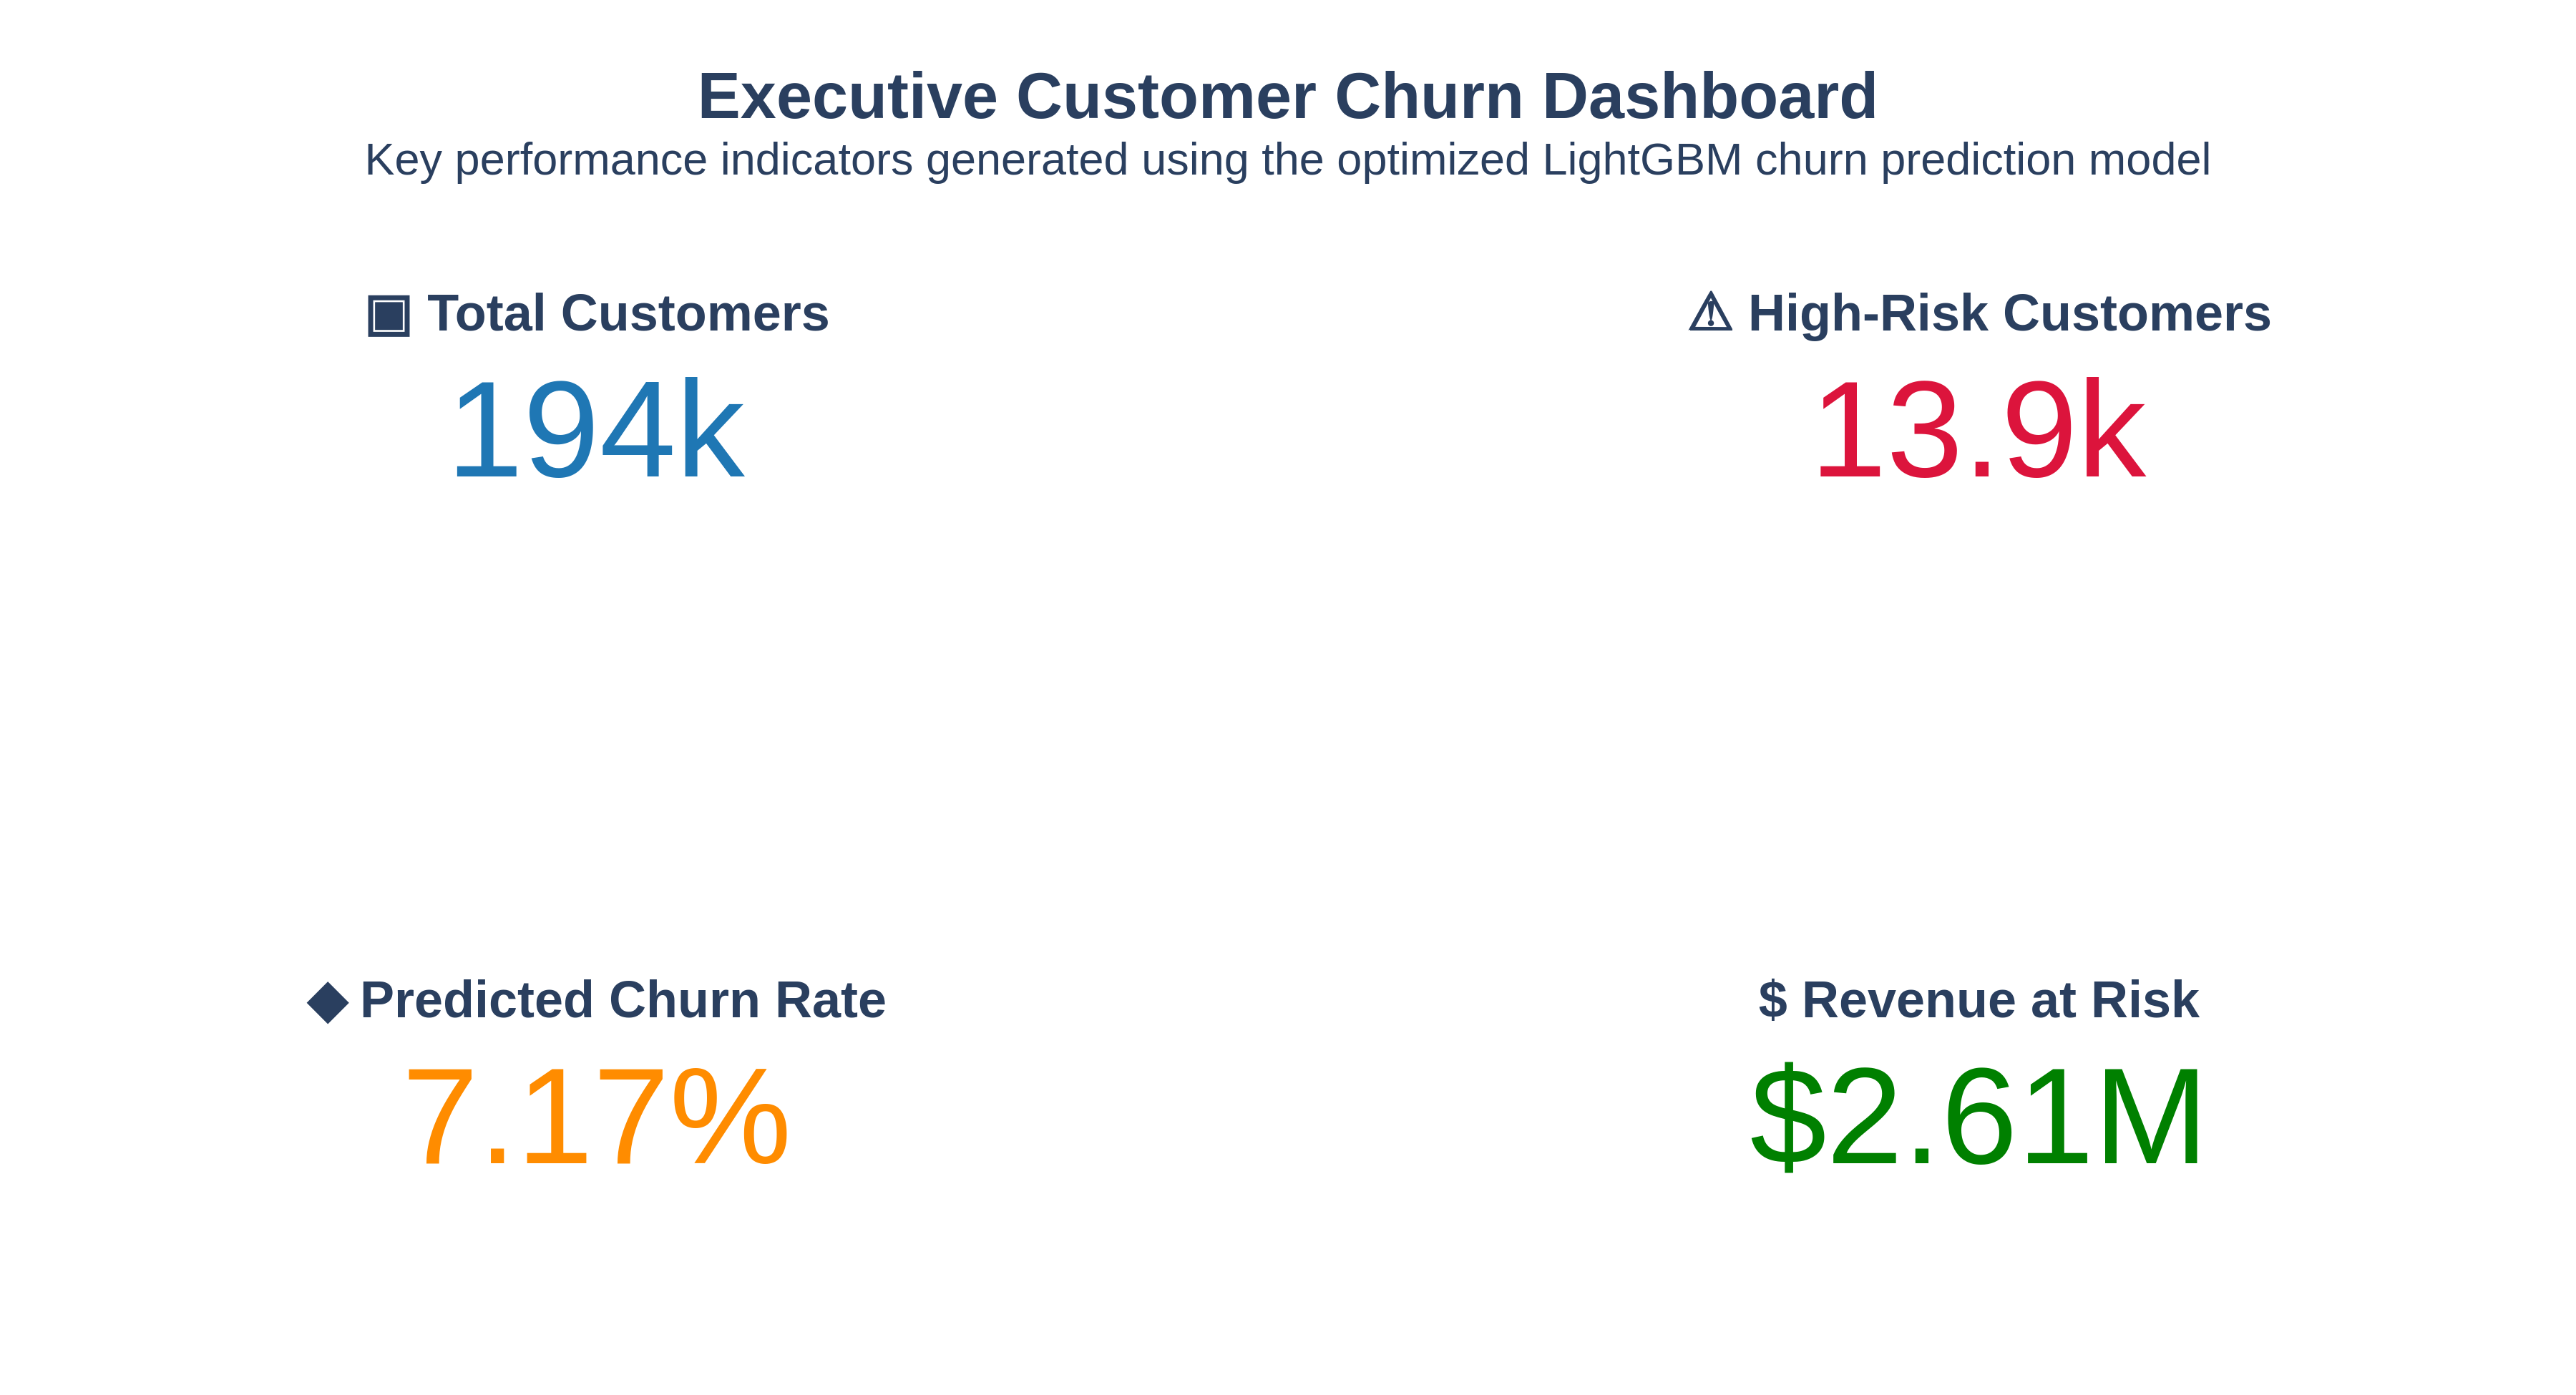

### Business Insight
- The model analyzed 194K customers and identified 13.9K customers as high-risk of churn.
- 7.17% of customers were classified as high-risk by the churn prediction model and should be prioritized for retention initiatives.
These customers represent the highest-priority segment for proactive retention efforts.
-  Based on an assumed average monthly subscription value of \$149 per customer, the potential revenue at risk is estimated at approximately \$2.61M. This figure is illustrative and demonstrates how churn predictions can be translated into business impact.

### Business Recommendations

- Prioritize personalized retention campaigns for high-risk customers before their subscriptions expire.
- Offer targeted incentives (discounts, premium trials, or loyalty rewards) only to customers with the highest predicted churn probability.
Continuously monitor model predictions to measure retention performance and update intervention strategies.
- Focus marketing resources on customers most likely to churn to maximize return on retention spending.

In [ ]:
risk_counts = (
    business_df["Risk Level"]
    .value_counts()
    .reset_index()
)
risk_counts.columns = [
    "Risk Level",
    "Customers"
]

fig = make_subplots(
    rows= 1,
    cols= 2,
    specs= [[{'type': 'xy'}, {'type': 'domain'}]],
    subplot_titles= ('Customer Churn Risk Distribution',
                      'Customer Risk Segmentation')
)
# Bar chart
fig.add_trace(
    go.Bar(
        x= risk_counts['Risk Level'],
        y= risk_counts['Customers'],
        text= risk_counts['Customers'],
        textposition= 'outside',
        marker_color= '#4C78A8'
    ),

    row= 1,
    col= 1
)

# Pie Chart
fig.add_trace(
    go.Pie(
        labels=risk_counts["Risk Level"],
        values=risk_counts["Customers"],
        hole=0.35
    ),
    row=1,
    col=2
)

fig.update_layout(
    title={
        "text": "Customer Churn Risk Analysis",
        "x": 0.5
    },
    template="plotly_white",
    height=600,
    width=1300,
    showlegend=True
)

fig.update_xaxes(title_text="Risk Category", row=1, col=1)
fig.update_yaxes(title_text="Number of Customers", row=1, col=1)
fig.show()

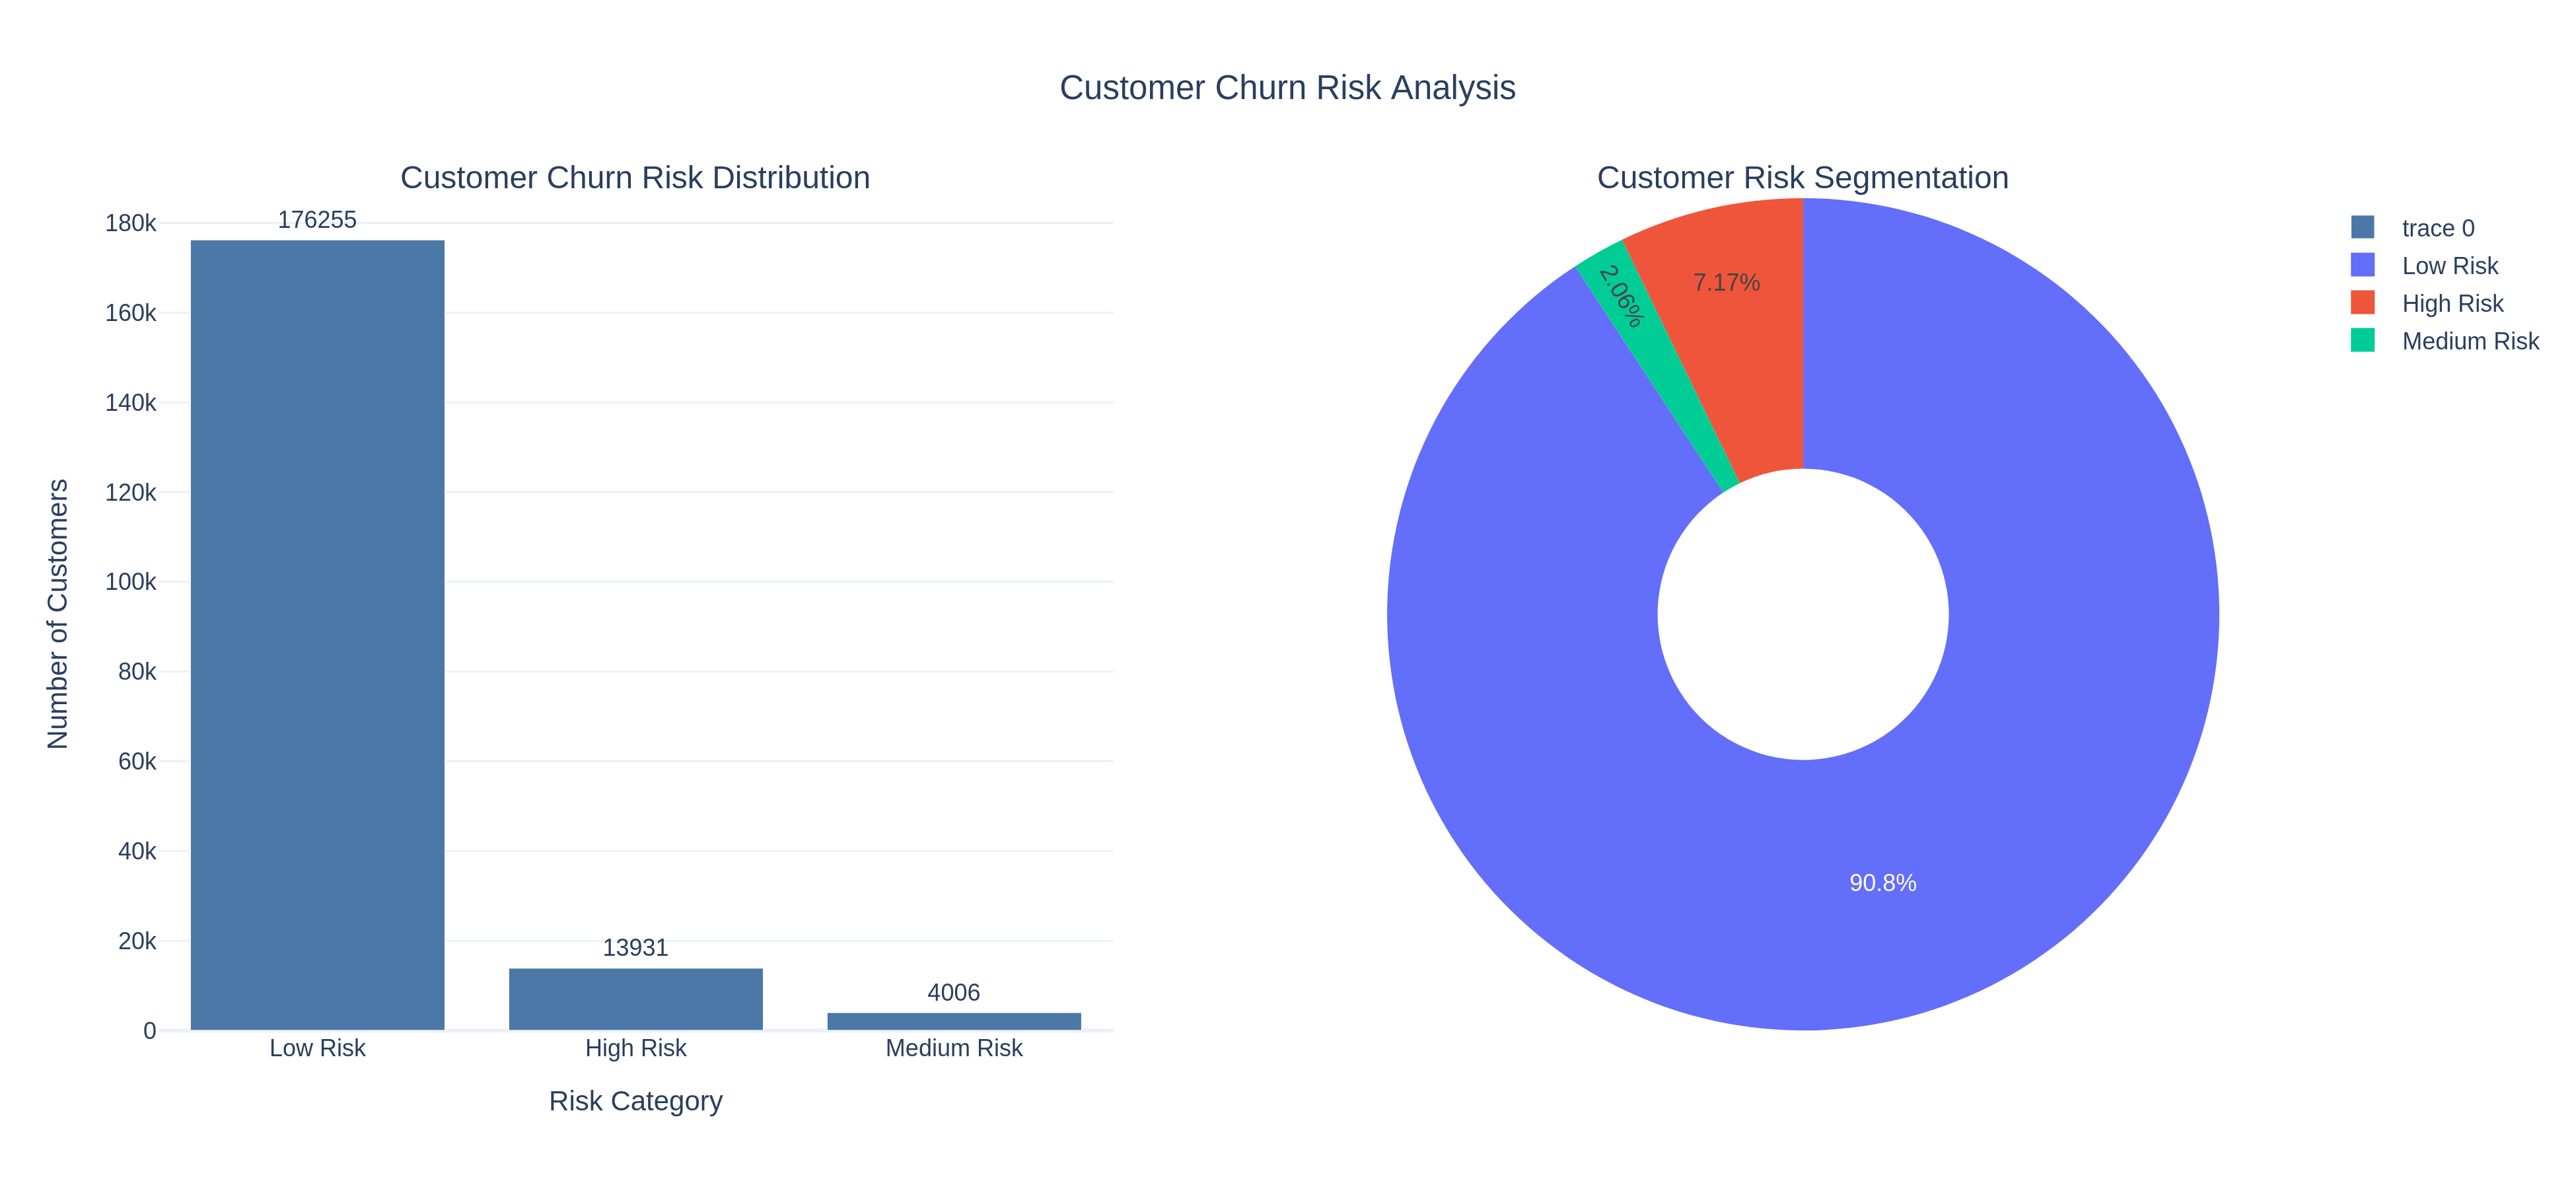

### Business Insight
- Most customers (90.8%) are classified as Low Risk, indicating a generally stable customer base.
- Only 7.17% of customers fall into the High-Risk segment, enabling retention efforts to focus on a relatively small, high-priority group.
- The Medium-Risk segment (2.06%) represents customers who could potentially transition to high risk without timely engagement.

### Business Recommendations
- Prioritize retention campaigns for High-Risk customers while monitoring Medium-Risk customers for early warning signs.
- Maintain customer satisfaction programs for the Low-Risk segment to preserve long-term loyalty.
- Review risk segment distributions regularly to measure the effectiveness of retention strategies and detect shifts in customer behavior.

##Customer Behavior Analysis

###Which customer behaviors indicate churn?

In [ ]:
fig = px.bar(
    behavior_summary.reset_index(),
    x="recent_activity_days",
    y="Risk Level",
    orientation="h",
    text=behavior_summary["recent_activity_days"].map(lambda x: f"{x:.1f}"),
    title="Average Recent Activity Days",
    color="Risk Level",
    height=550,
    width=1100
)

fig.update_traces(textposition="outside")
fig.update_yaxes(
    categoryorder="array",
    categoryarray=["High Risk","Medium Risk","Low Risk"]
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Days",
    yaxis_title="",
    showlegend=False
)
fig.show()

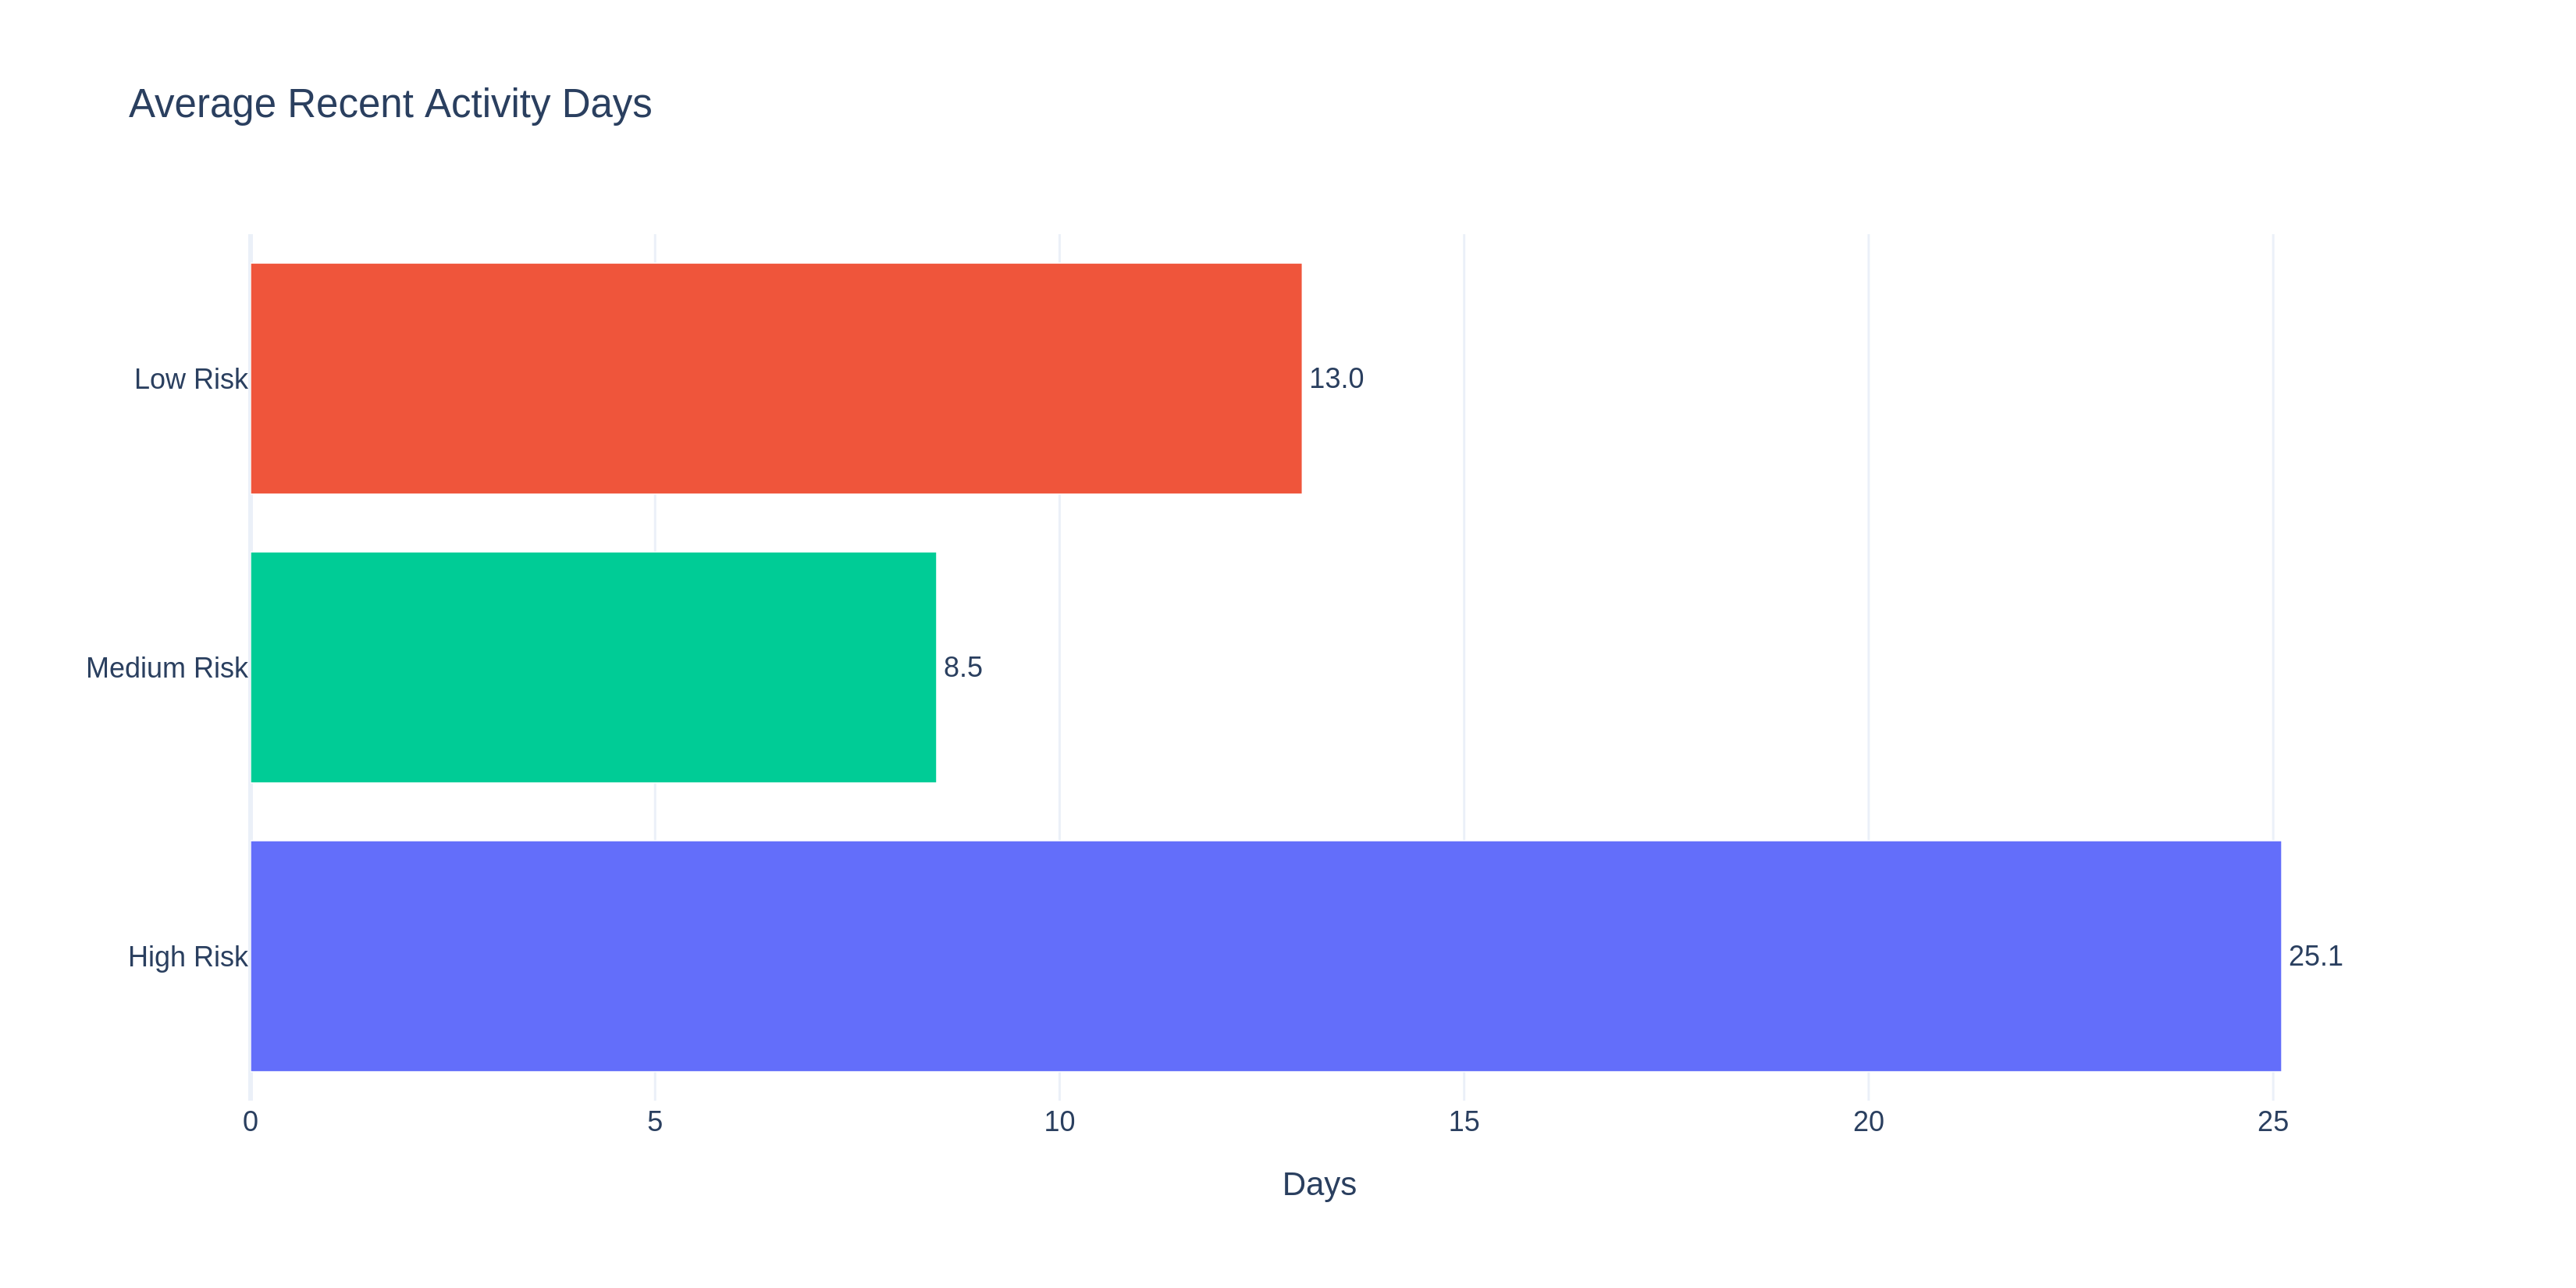

In [ ]:
days_log = (
    business_df
    .groupby("Risk Level", as_index=False)["days_since_last_log"]
    .mean()
)

fig = px.bar(
    days_log,
    x="days_since_last_log",
    y="Risk Level",
    orientation="h",
    color="Risk Level",
    text=days_log["days_since_last_log"].round(1),
    title="Average Days Since Last Log"
)

fig.update_traces(textposition="outside")

fig.update_yaxes(
    categoryorder="array",
    categoryarray=["High Risk","Medium Risk","Low Risk"]
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=550,
    showlegend=False,
    xaxis_title="Average Days",
    yaxis_title=""
)
fig.show()

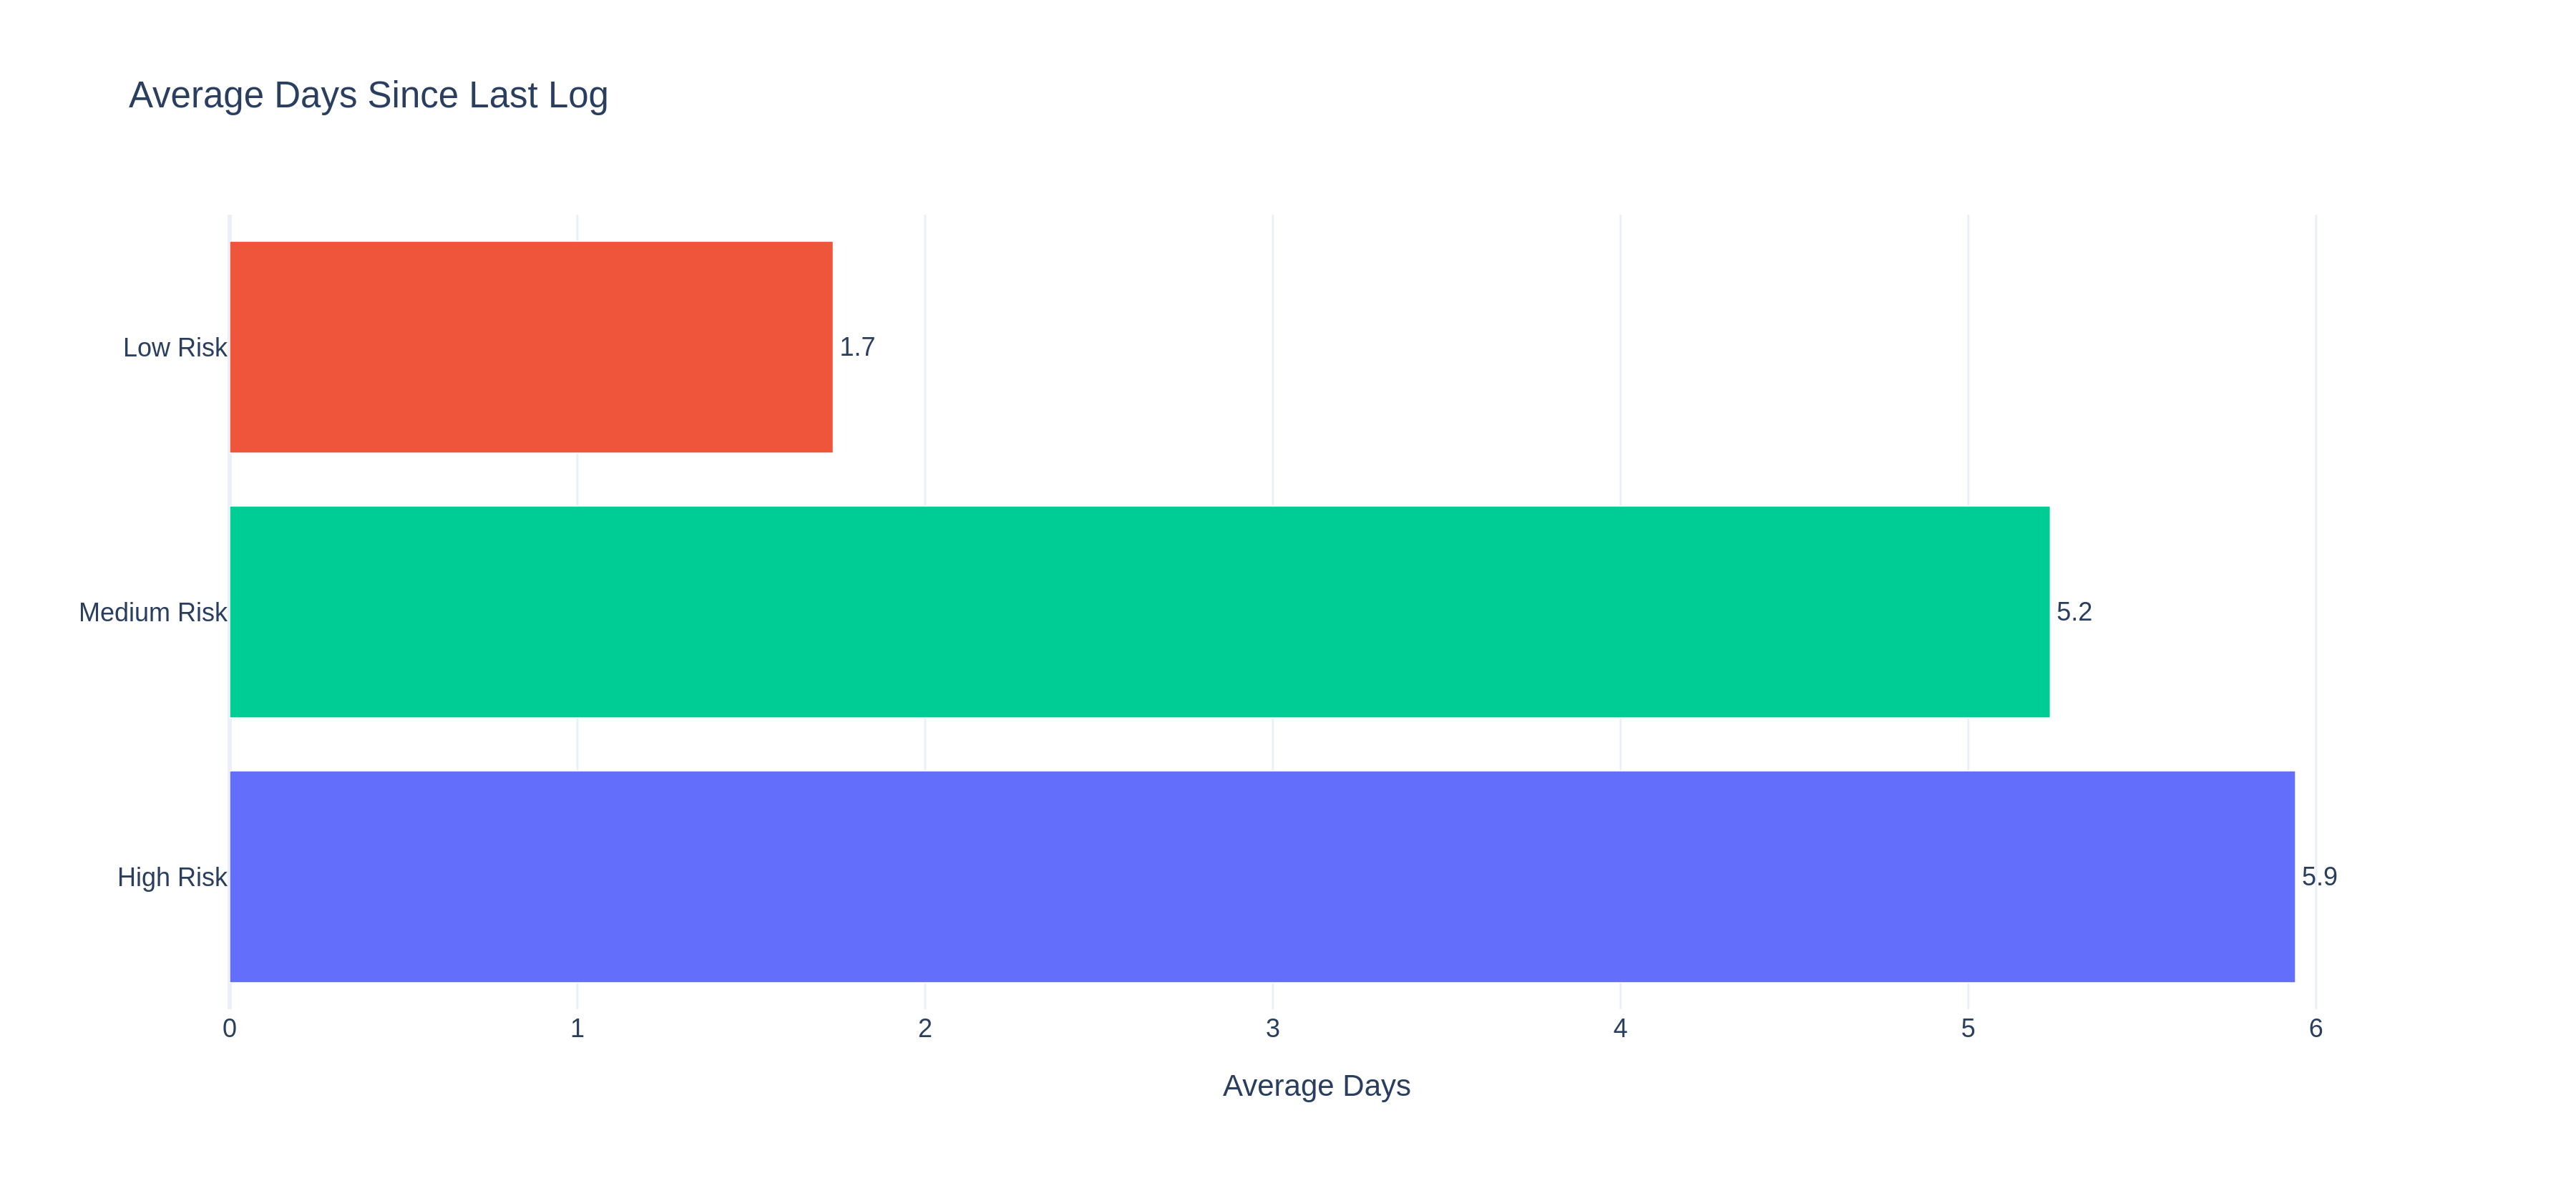

### Business Insight

High-risk customers exhibit significantly lower engagement. On average, they remain inactive for nearly twice as many days as low-risk customers and take longer to return to the platform. Declining engagement is a strong early indicator of potential churn.

### Business Recommendation
- Monitor customer inactivity using Recent Activity Days and Days Since Last Log as early warning indicators.
- Trigger automated re-engagement campaigns (personalized emails, push notifications, or content recommendations) when customers become inactive.
- Prioritize retention efforts for customers showing sustained declines in platform engagement.

## Subscription Analysis

### Which subscription patterns increase churn risk?

In [ ]:
expiry = (
    business_df
    .groupby("Risk Level", as_index=False)["days_to_expiry_at_cutoff"]
    .mean()
)

fig = px.bar(
    expiry,
    x="days_to_expiry_at_cutoff",
    y="Risk Level",
    orientation="h",
    color="Risk Level",
    text=expiry["days_to_expiry_at_cutoff"].round(1),
    title="Average Days Until Subscription Expiry"
)

fig.update_traces(textposition="outside")

fig.update_yaxes(
    categoryorder="array",
    categoryarray=["High Risk","Medium Risk","Low Risk"]
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=550,
    showlegend=False,
    xaxis_title="Average Days",
    yaxis_title=""
)
fig.show()

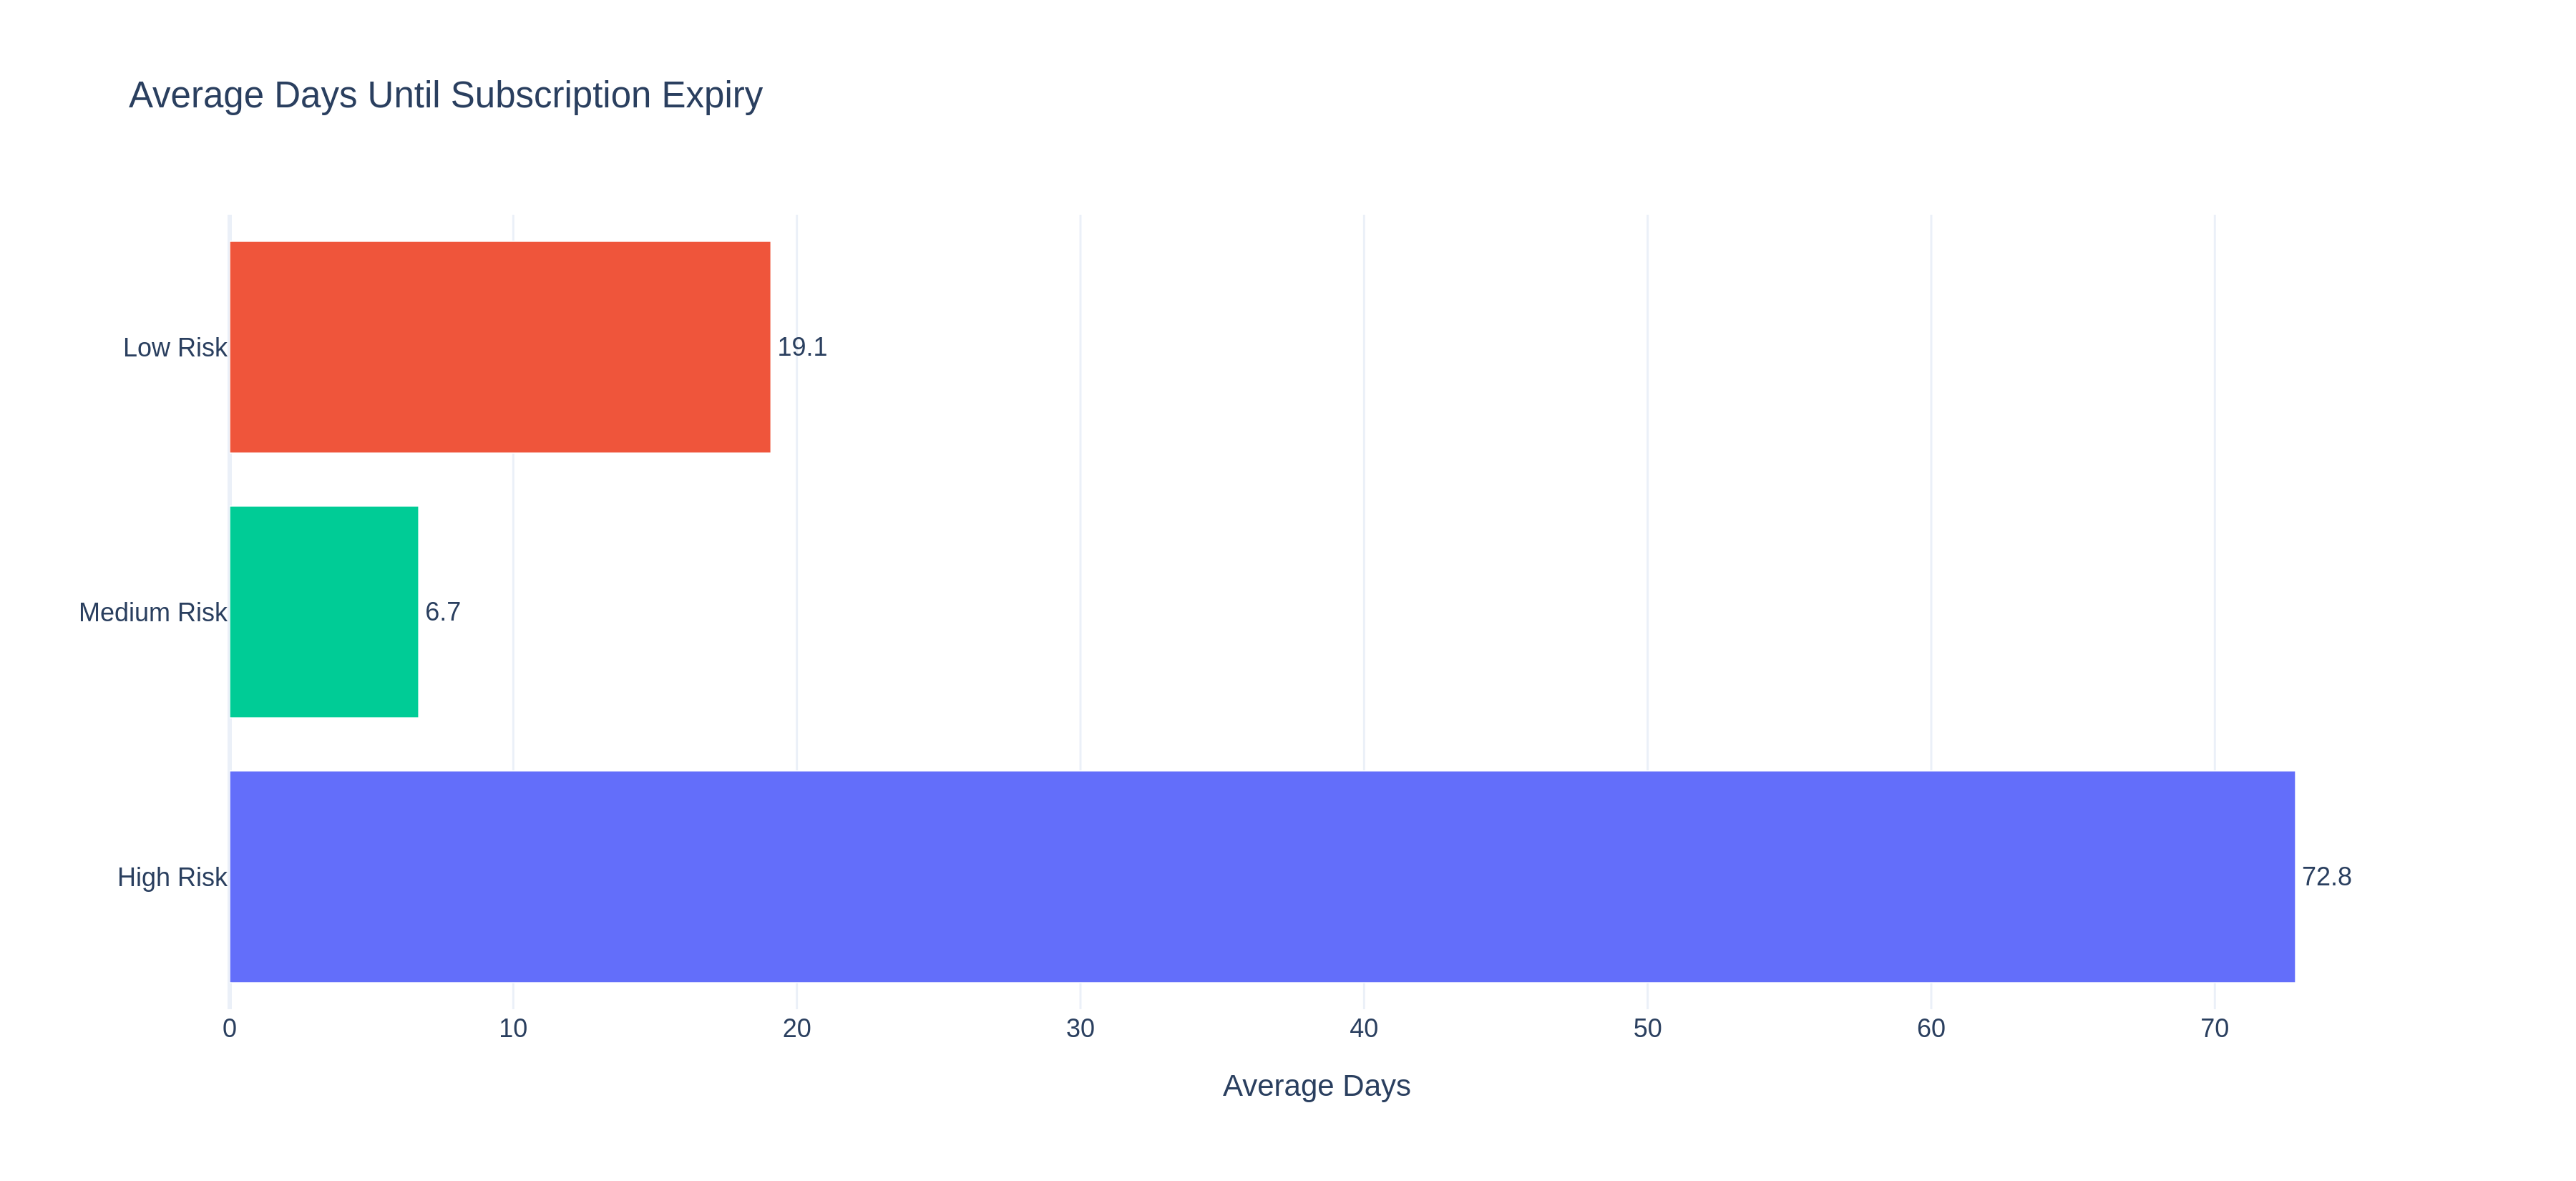

In [ ]:
membership = (
    business_df
    .groupby("Risk Level", as_index=False)["avg_membership_duration"]
    .mean()
)

fig = px.bar(
    membership,
    x="avg_membership_duration",
    y="Risk Level",
    orientation="h",
    color="Risk Level",
    text=membership["avg_membership_duration"].map(lambda x: f"{x:.1f}"),
    title="Average Membership Duration"
)

fig.update_traces(textposition="outside")

fig.update_yaxes(
    categoryorder="array",
    categoryarray=["High Risk","Medium Risk","Low Risk"]
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=550,
    showlegend=False,
    xaxis_title="Average Days",
    yaxis_title=""
)
fig.show()

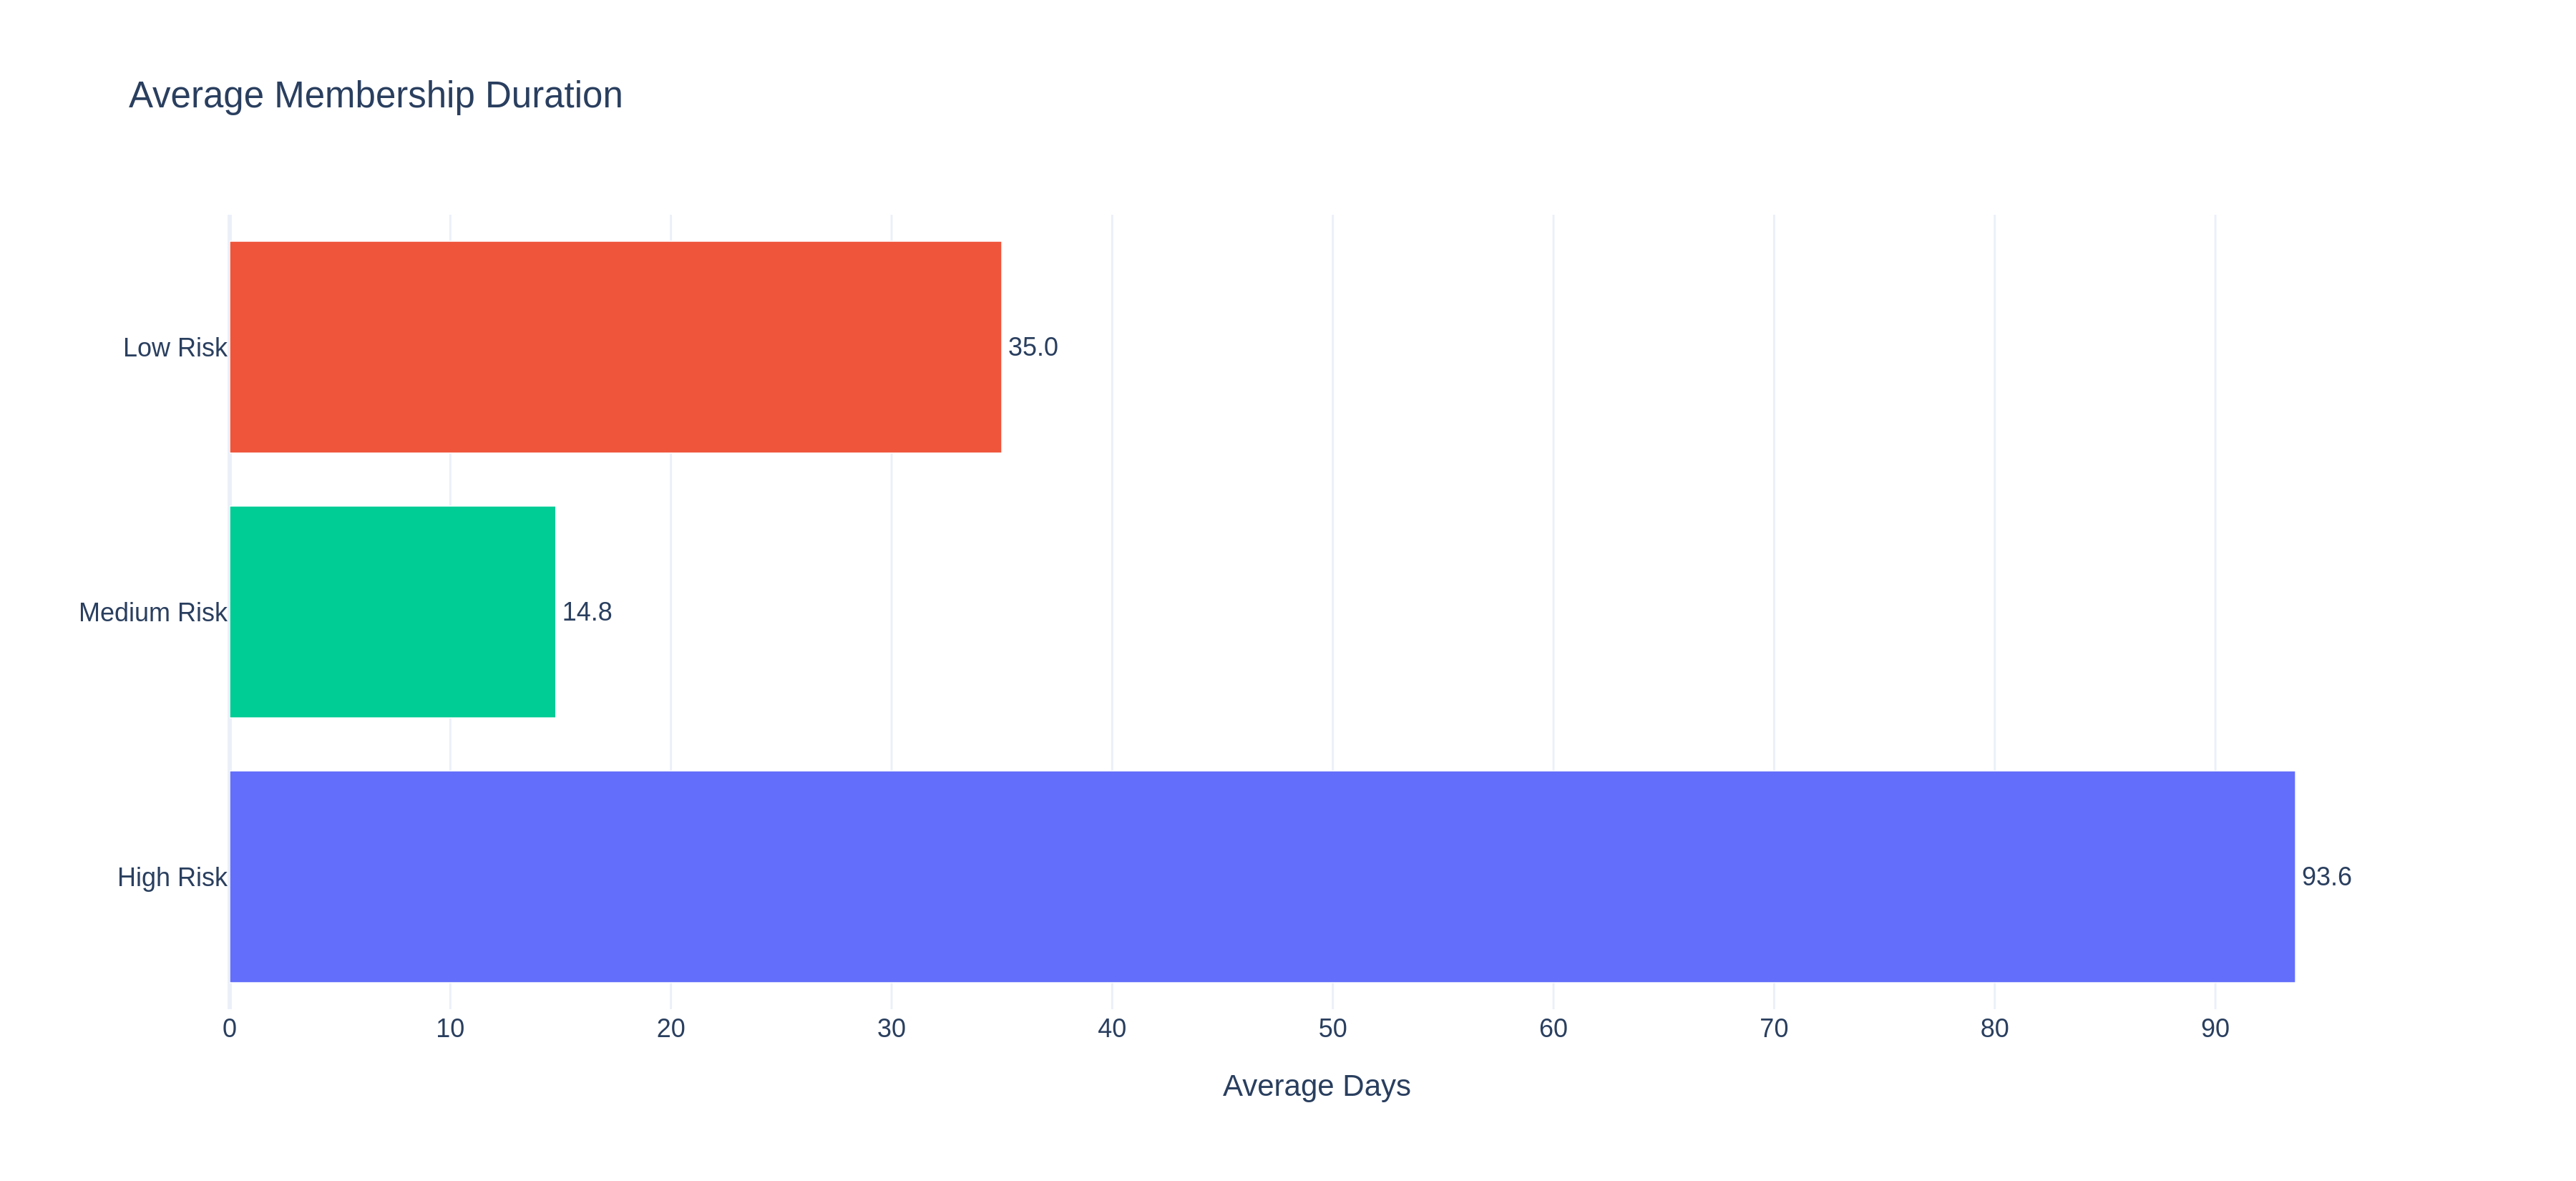

### Business Insight

- High-risk customers have maintained subscriptions much longer than other groups, indicating that churn is often driven by long-term disengagement rather than by new customers leaving immediately.
- High-risk customers still have, on average, over two months remaining before subscription expiry. This suggests many customers disengage long before their subscription ends, providing a valuable window for proactive retention campaigns.

### Business Recommendation
- Identify long-term subscribers who have become disengaged and offer loyalty incentives or exclusive benefits before renewal decisions are made.
- Monitor customers with substantial remaining subscription time but declining activity, as they may require proactive intervention despite not being close to expiration.
- Segment retention campaigns based on subscription lifecycle, ensuring experienced subscribers receive different offers than newer customers.

## Customer Segmentation

### Which types of customers are more likely to churn?

### Age Risk Analysis

In [ ]:
counts = business_df.groupby("bd").size()

# Keep only age with at least 500 customers
valid_methods = counts[counts >= 500].index

# Filter dataframe
plot_df = business_df[
    business_df["bd"].isin(valid_methods)
].copy()

# Compute average churn
age = (
    plot_df
    .groupby("bd", as_index=False)
    .agg(
        Count=("Churn Probability", "size"),
        Avg_Churn=("Churn Probability", "mean")
    )
    .sort_values("Avg_Churn", ascending=False)
)

print(age)

In [ ]:
Age = (
    age
    .groupby("bd", as_index=False)["Avg_Churn"]
    .mean()
)

fig = px.bar(
    age,
    x="bd",
    y="Avg_Churn",
    title="Average Predicted Churn by Age",
    text=age["Avg_Churn"].round(2)
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=550,
    xaxis_title="Age",
    yaxis_title="Average Churn Probability"
)
fig.show()

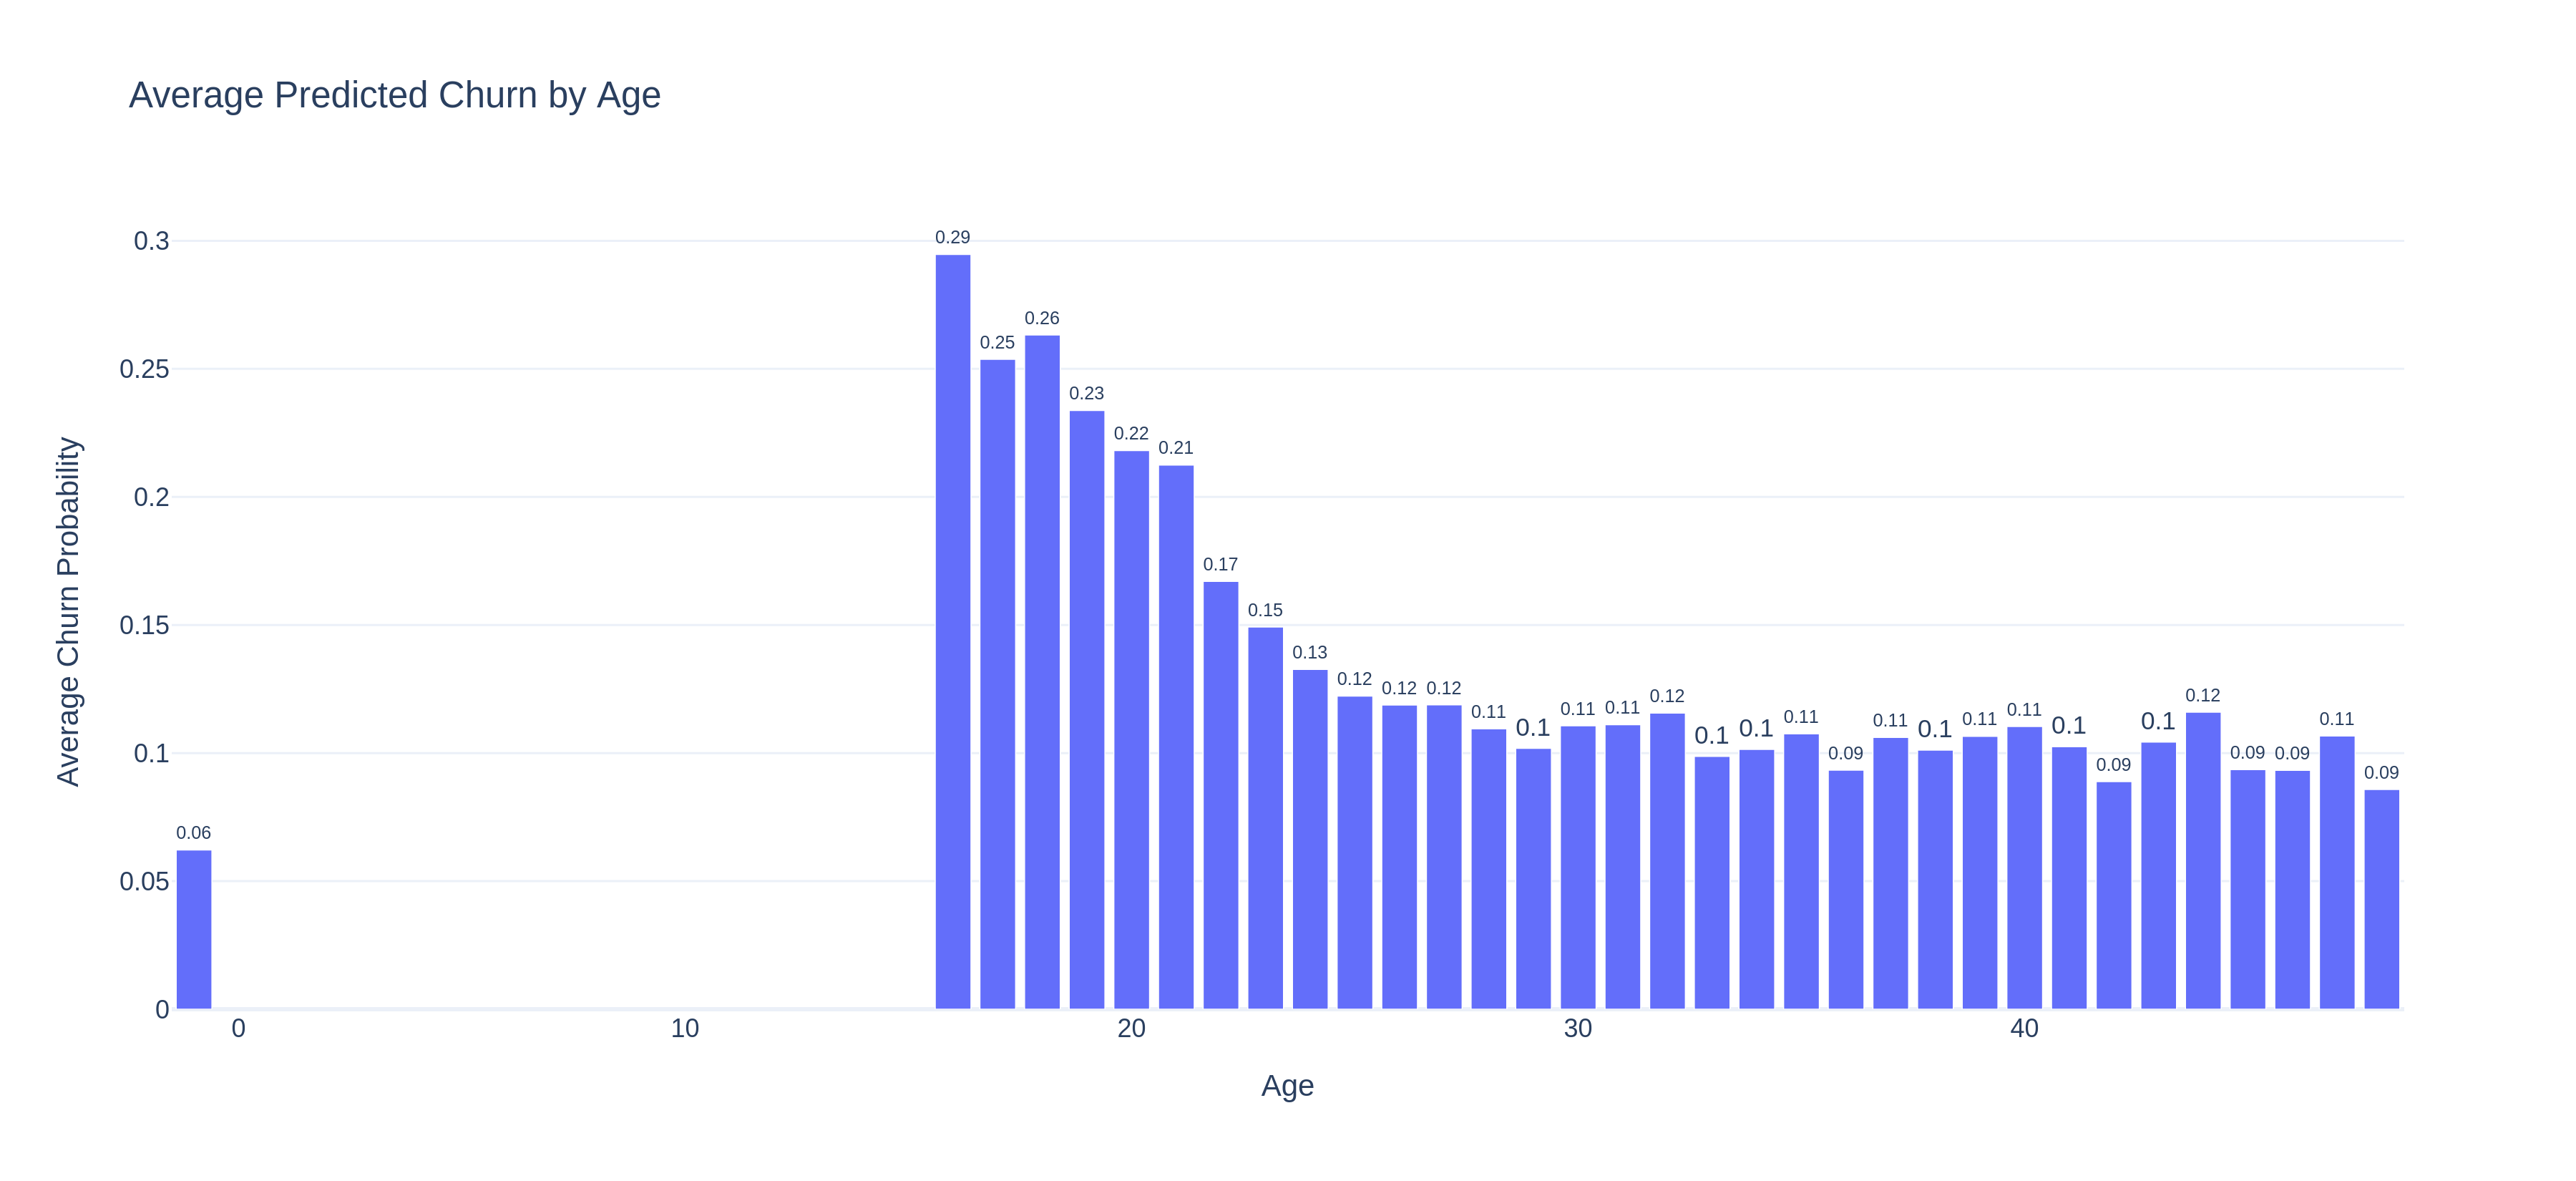

### Business Insight
- Customers aged 16–22 have the highest predicted churn probability, with risk gradually decreasing as age increases.
- After approximately 25 years old, churn becomes relatively stable with only small differences between age groups.
- This indicates that younger customers are substantially more volatile, while older customers exhibit more consistent subscription behavior.
The isolated value for age 0 has a very small probability and likely represents missing or unknown age rather than a real customer segment, so it should not drive business decisions.

### Business Recommendation
- Develop a youth-focused retention strategy instead of applying identical campaigns to every customer.
- Introduce personalized onboarding, early engagement campaigns, and student or young-user promotions during the first months after registration.
- Allocate retention budget preferentially toward younger customers because they present the greatest opportunity for reducing future churn.

### Acquisition Channel Analysis

In [ ]:
reg = (
    business_df
    .groupby("registered_via", as_index=False)["Churn Probability"]
    .mean()
    .sort_values("Churn Probability", ascending=False)
)

fig = px.bar(
    reg,
    x="registered_via",
    y="Churn Probability",
    title="Average Predicted Churn by Registration Method",
    text=reg["Churn Probability"].round(2)
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=550,
    xaxis_title="Registration Method",
    yaxis_title="Average Churn Probability"
)
fig.show()

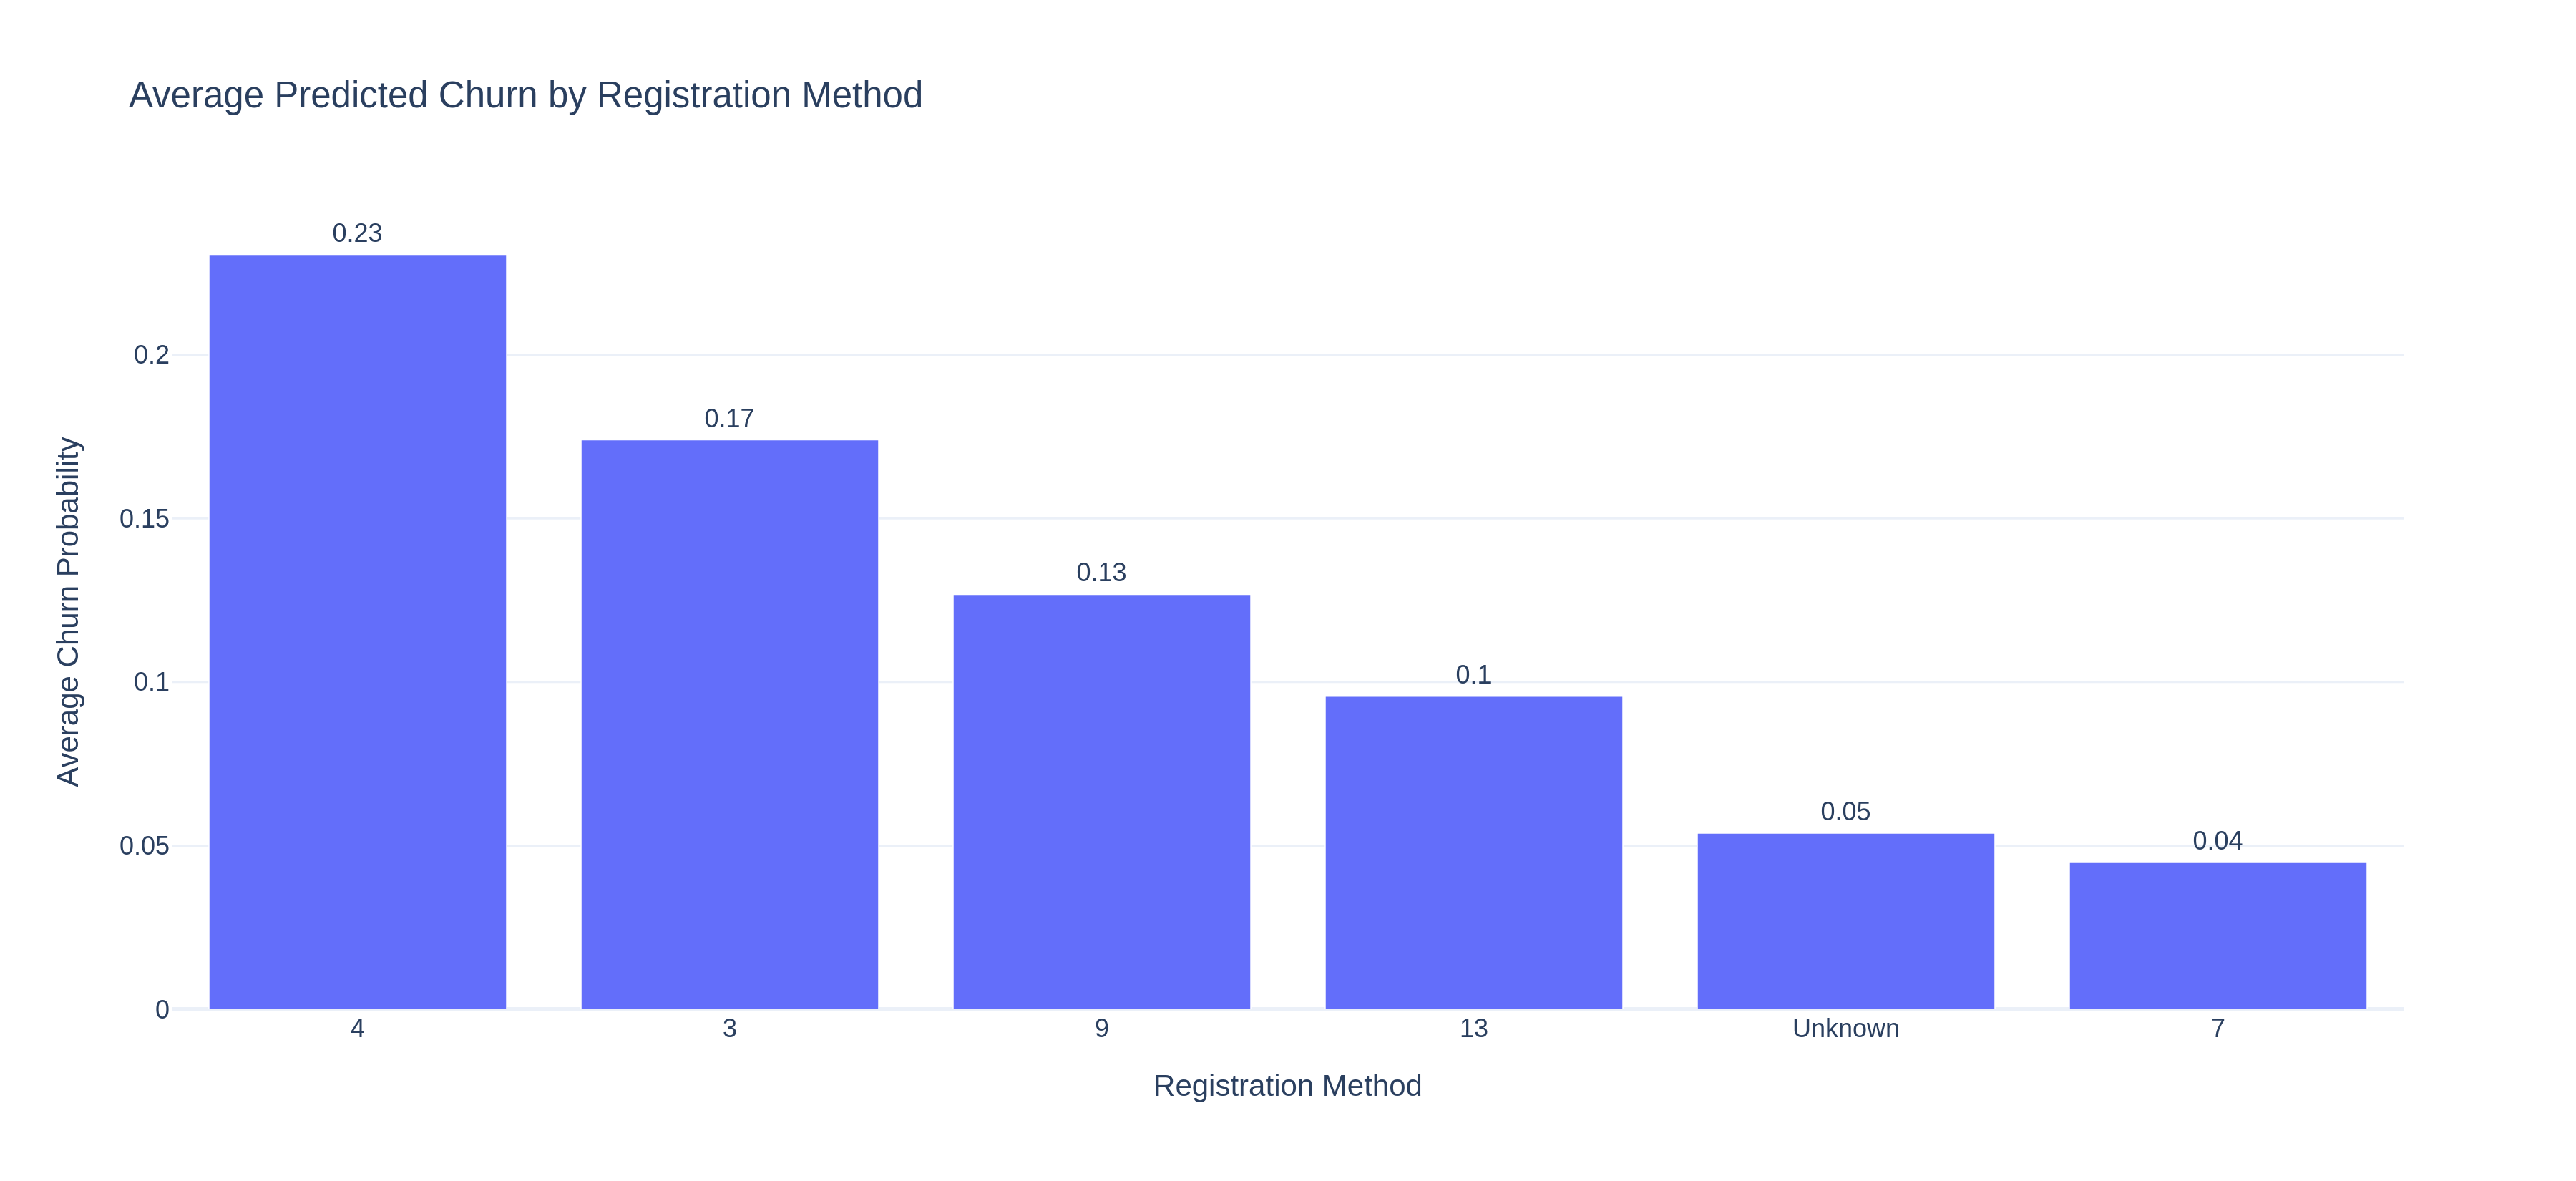

### Business Insight
- Registration methods differ noticeably in predicted churn.
Method 4 produces the highest average churn probability, followed by methods 3 and 9.
- Method 7 and customers with unknown registration methods exhibit substantially lower churn.
- This suggests that customer acquisition quality varies across registration channels, meaning some channels attract less loyal users than others.

### Business Recommendation
- Evaluate the marketing campaigns associated with high-risk registration channels rather than simply increasing acquisition volume.
- Compare conversion quality, onboarding experience, and customer lifetime value across registration methods.
- Optimize or discontinue acquisition campaigns that consistently attract customers with poor long-term retention.

### Payment Behavior Analysis

In [ ]:
# Count customers per payment method
counts = business_df.groupby("last_payment_method").size()

# Keep only payment methods with at least 500 customers
valid_methods = counts[counts >= 500].index

# Filter dataframe
plot_df = business_df[
    business_df["last_payment_method"].isin(valid_methods)
].copy()

# Compute average churn
payment = (
    plot_df
    .groupby("last_payment_method", as_index=False)
    .agg(
        Count=("Churn Probability", "size"),
        Avg_Churn=("Churn Probability", "mean")
    )
    .sort_values("Avg_Churn", ascending=False)
)

print(payment)

In [ ]:
fig = px.bar(
    payment,
    x="last_payment_method",
    y="Avg_Churn",
    text=payment["Avg_Churn"].round(2),
    title="Average Predicted Churn by Payment Method"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=550,
    xaxis_title="Payment Method",
    yaxis_title="Average Predicted Churn Probability"
)
fig.show()

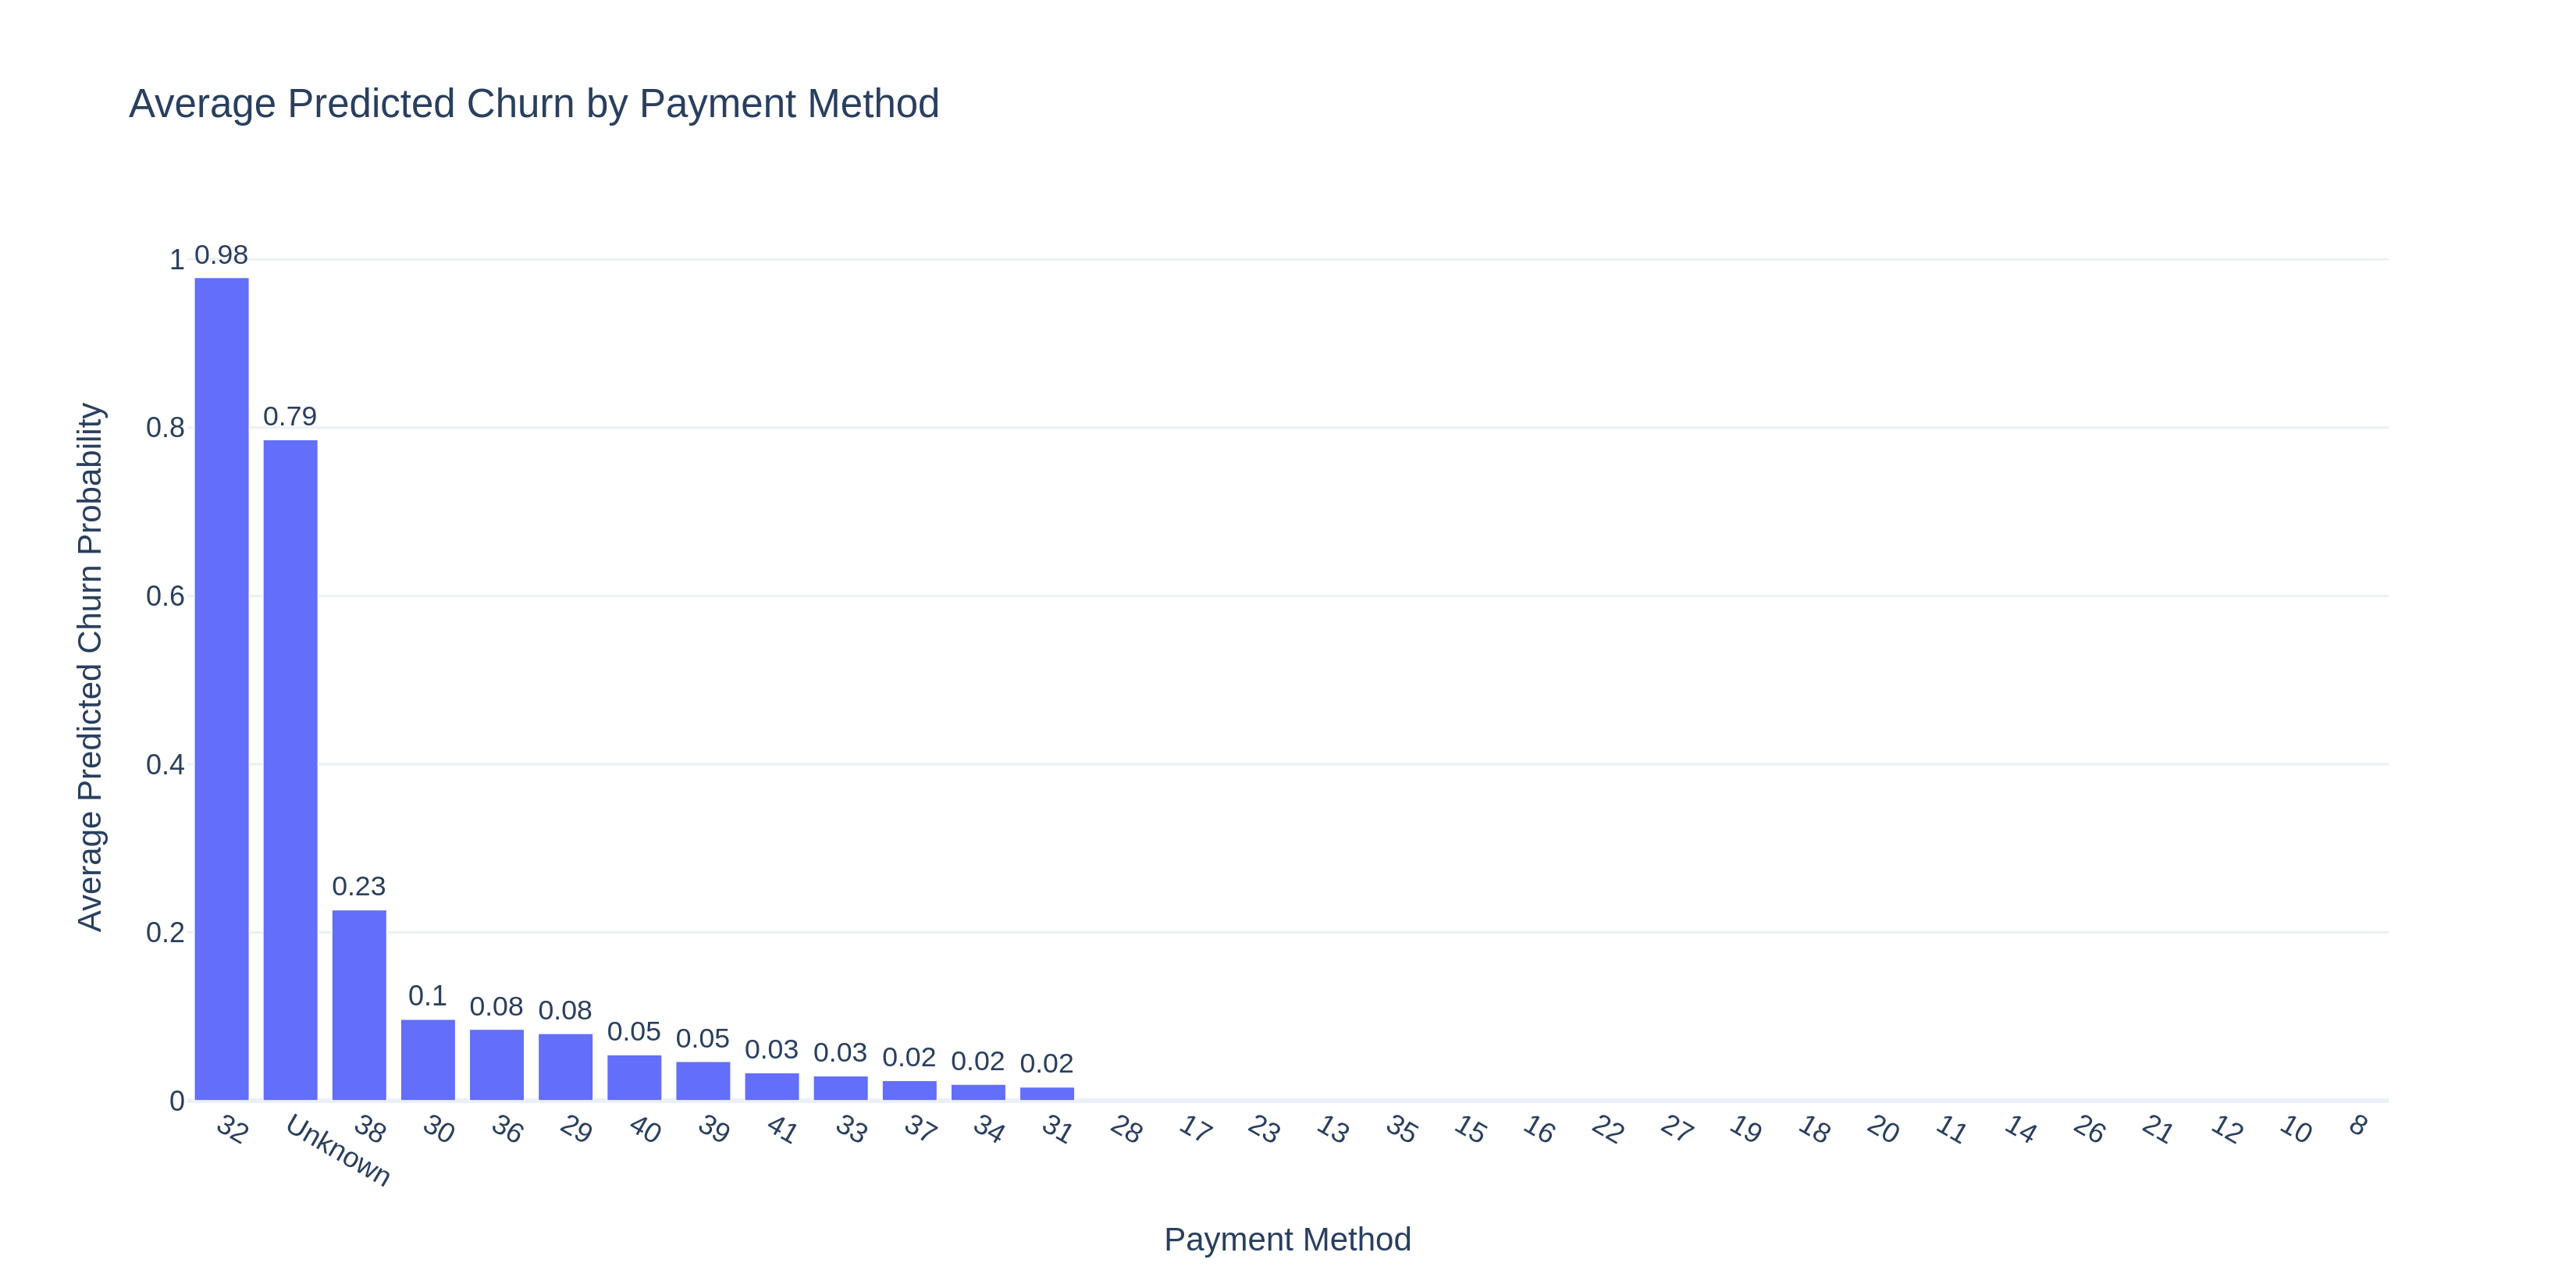

### Business Insight
- Payment method 32 exhibits an exceptionally high predicted churn probability (~98%), while customers with unknown payment methods also show elevated churn.
- Most remaining payment methods demonstrate relatively low churn probabilities, indicating that churn risk is concentrated within only a few payment categories.
- The results suggest that payment behavior is an important behavioral indicator rather than merely a billing attribute.
The model identifies payment method as an early signal of future churn, implying that differences in payment workflows or customer preferences may influence retention.

### Business Recommendation
- Investigate why customers using payment method 32 consistently experience extremely high churn.
- Review whether these customers encounter payment failures, short-term subscription plans, manual renewals, or poorer user experiences.
- Implement targeted retention campaigns for customers using high-risk payment methods before their subscriptions expire.
- Monitor payment-method performance continuously to detect newly emerging high-risk payment behaviors.

### Top 20 Most Important Features (LightGBM)

,Feature,Importance
47,days_to_expiry_at_cutoff,1444
38,avg_membership_duration,1151
34,recent_activity_days,1137
7,member_tenure_days,834
54,total_secs_min,724
71,days_since_last_log,641
1,bd,566
59,num25_sum,563
66,completion_rate,563
67,skip_rate,560


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

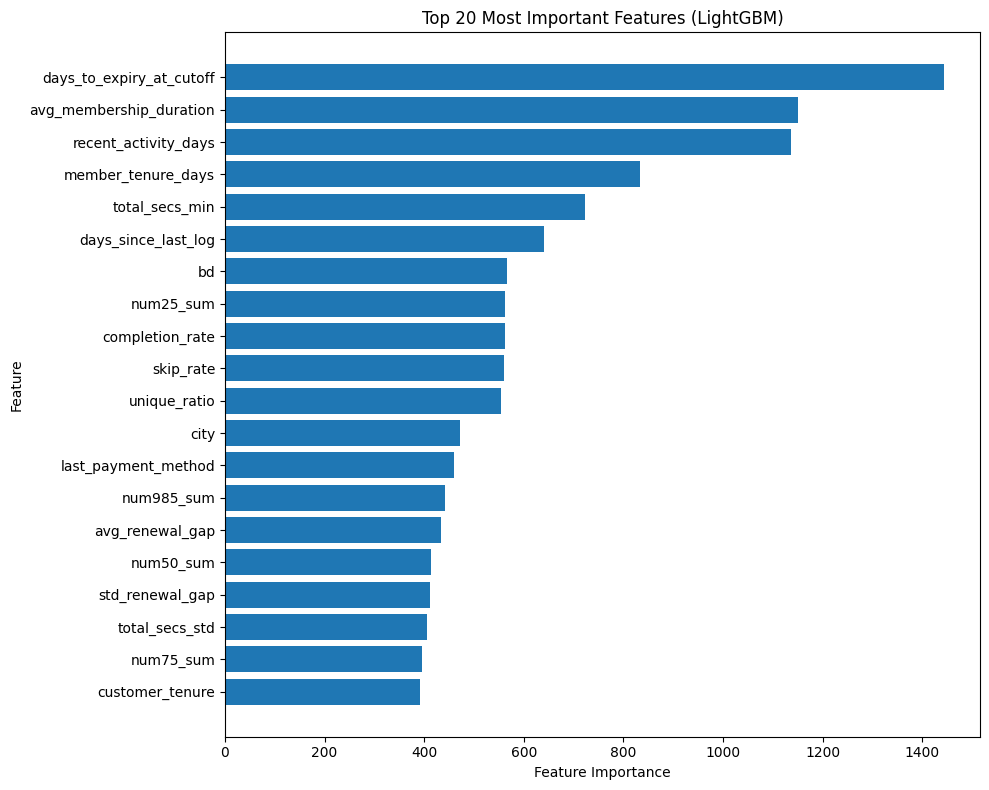

In [ ]:
# ==========================================================
# LightGBM Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature": model.feature_name_,

    "Importance": model.feature_importances_

})

importance = (
    importance
    .sort_values("Importance", ascending=False)
    .head(20)
)

display(importance)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][::-1],
    importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features (LightGBM)")

plt.tight_layout()
plt.show()

## What features drive churn across all customers?

### Explainable AI (SHAP)
To ensure model predictions are transparent and actionable, SHAP (SHapley Additive exPlanations) was used to identify the features that most strongly influence churn predictions at both the global and individual customer levels.

In [ ]:
X_shap = X_test_pd.sample(
    n=5000,
    random_state=SEED
)

In [ ]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

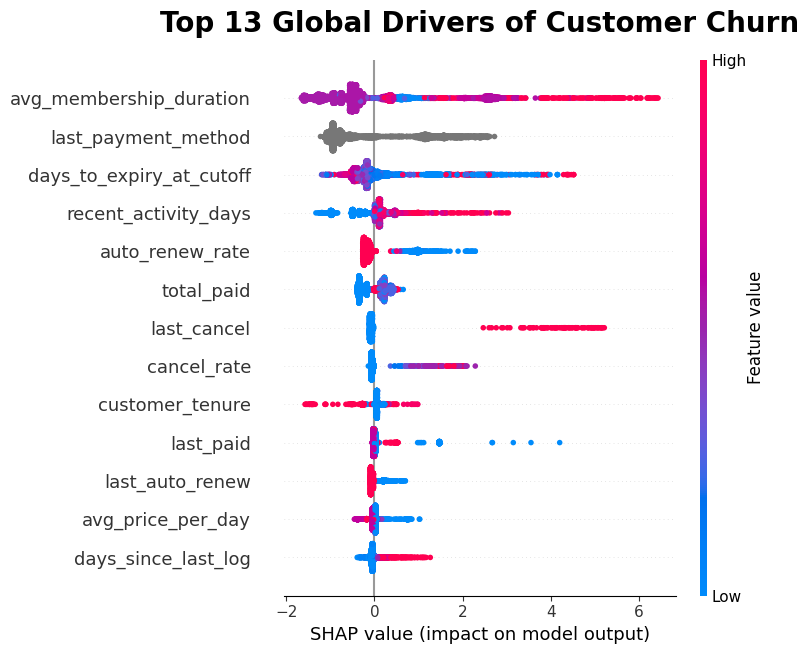

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 14
})

plt.figure(figsize=(13,8))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=13,
    show=False
)

plt.title(
    "Top 13 Global Drivers of Customer Churn",
    fontsize=20,
    weight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

### Business Insight

- The SHAP analysis reveals that the model primarily learns from customer behavior rather than demographic attributes. Instead of relying on age or registration channel, the model combines subscription history, payment behavior, renewal patterns, and cancellation signals to estimate churn risk. This demonstrates that customer engagement throughout the subscription lifecycle is far more informative than static profile information.

### Business Recommendation
- Organizations should build churn monitoring systems around behavioral signals rather than demographic segmentation alone. Combining explainable AI with predictive models enables customer success teams to understand the primary drivers behind each prediction, prioritize high-risk customers more effectively, and design targeted retention strategies based on the underlying causes of churn instead of applying generic campaigns.

##Why was this individual customer predicted to churn?

In [ ]:
customer = 15
explanation = shap.Explanation(
    values=shap_values[customer],
    base_values=explainer.expected_value,
    data=X_shap.iloc[customer],
    feature_names=X_shap.columns
)

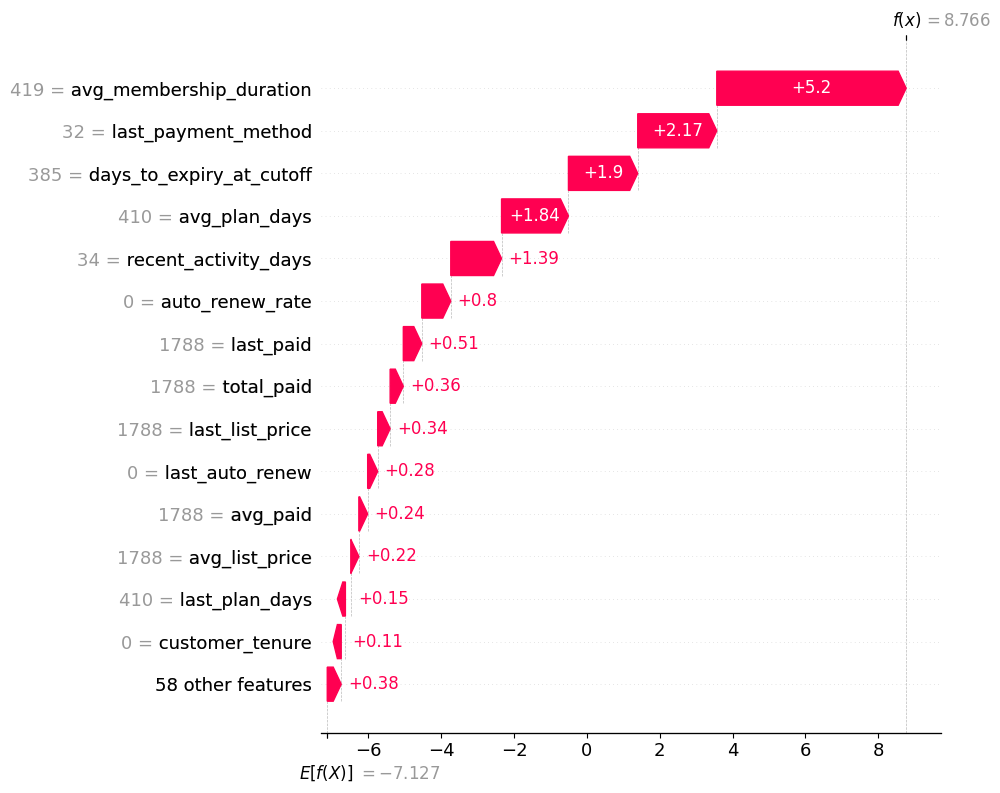

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Find highest-risk customer
probs_for_shap = model.predict_proba(X_shap)[:, 1]
highest_risk_idx_in_shap = probs_for_shap.argmax()

# Create SHAP explanation
explanation = shap.Explanation(
    values=shap_values[highest_risk_idx_in_shap],
    base_values=explainer.expected_value,
    data=X_shap.iloc[highest_risk_idx_in_shap],
    feature_names=X_shap.columns
)

# Create the waterfall plot
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.show()

### Business Insight

- The individual SHAP explanation shows that churn predictions are driven by the combined influence of multiple behavioral signals rather than any single feature. Although the customer still has an active subscription and auto-renew provides a small protective effect, the model identifies a pattern of renewal behavior, subscription history, and declining engagement that outweighs these positive factors, resulting in an extremely high churn risk.

### Business Recommendation

- Instead of using one-size-fits-all retention campaigns, organizations should use explainable AI to understand the specific factors driving churn for each customer. Personalized interventions can then focus on the customer's underlying risk profile—for example, addressing declining engagement, reviewing renewal behavior, or offering loyalty incentives—rather than applying the same retention strategy to every at-risk subscriber.